# Close ECCO v5 (LLC270) Arctic tile heat budget

This notebook calculates the heat budget for each vertical level of the ECCO LLC270 v5 Arctic tile

***

Here we follow procedures outlined in the [ECCO tutorial](https://ecco-v4-python-tutorial.readthedocs.io/ECCO_v4_Heat_budget_closure.html#). In summary:

#### ECCO v5

The total tendency of $\theta$ ($G^{\theta} _\textrm{total}$) is the sum of the $\theta$ tendencies from advective heat convergence ($G^{\theta}_\textrm{advection}$), diffusive heat convergence ($G^{\theta}_\textrm{diffusion}$) and total forcing ($G^{\theta}_\textrm{forcing}$).

In the special case of ECCOv4, the heat budget is formulated as
\begin{equation}
\underbrace{\frac{\partial(s^*\theta)}{\partial t}}_{G^{\theta}_\textrm{total}} = \underbrace{-\nabla_{z^{*}} \cdot(s^*\theta\,\mathbf{v}_{res}) - \frac{\partial(\theta\,w_{res})}{\partial z^{*}}}_{G^{\theta}_\textrm{advection}}\underbrace{- s^* ({\nabla\cdot\mathbf{F}_\textrm{diff}^{\theta}})}_{G^{\theta}_\textrm{diffusion}} + \underbrace{s^* {F}_\textrm{forc}^{\theta}}_{G^{\theta}_\textrm{forcing}}
\end{equation}

where $z^{*} = \frac{z - \eta}{H + \eta}H$ and $\nabla_{z^{*}}$/$\frac{\partial}{\partial z^{*}}$ are horizontal/vertical divergences in the $z^*$ frame. The advection is separated into horizontal ($\mathbf{v}_{res}$) and vertical ($w_{res}$) components, and there is a scaling factor ($s^* = 1+ \frac{\eta}{H}$) applied to the horizontal advection as well as the diffusion term ($G^{\theta}_\textrm{diffusion}$) and forcing term ($G^{\theta}_\textrm{forcing}$). $s^*$ is a function of $\eta$ which is the displacement of the ocean surface from its resting position of $z=0$ (i.e., sea height anomaly). $H$ is the ocean depth. $s^{*}$ comes from the coordinate transformation from z to $z^*$ (Campin and Adcroft, 2004; Campin et al., 2004).

Note that the velocity terms in the ECCOv4 heat budget equation ($\mathbf{v}_{res}$ and $w_{res}$) are described as the "residual mean" velocities, which contain both the resolved (Eulerian) flow field, as well as the "GM bolus" velocity (i.e., parameterizing unresolved eddy effects):

$$(u_{res},v_{res},w_{res})= (u,v,w)+ (u_b,v_b,w_b)$$

Here $(u_b,v_b,w_b)$ is the bolus velocity parameter, taking into account the correlation between velocity and thickness (also known as the eddy induced transportor the eddy advection term).


***

In [69]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import timedelta, datetime
import glob
import os
import re

## import ECCO utils
import sys
sys.path.append('/Users/mzahn/github_others/ECCOv4-py')
import ecco_v4_py as ecco

In [72]:
def load_eccov5_bin_data(
    data_dir='/home/jpluser/efs-mount-point/mzahn/data/ecco_v5/THETA_mon_mean',
    geometry_path='/home/jpluser/efs-mount-point/mzahn/data/ecco_v5/grid/ECCO-GRID.nc'):
    
    geom = xr.open_dataset(geometry_path)
    
    # --- List and sort all .data files
    files = sorted(Path(data_dir).glob("*.data"))
    print(f"Found {len(files)} .data files")

    # create monthly time coordinate (15th of each month from Jan 1992 to Dec 2024)
    time_coord = pd.date_range("1992-01-01", "2024-12-01", freq="MS") + pd.Timedelta(days=14)
    
    # sanity check
    if len(files) != len(time_coord):
        print(f"Warning: {len(files)} files but {len(time_coord)} time steps! Time coord will be truncated.")
        time_coord = time_coord[:len(files)]

    # load all files into xarray DataArrays
    arrays = []
    for i, filepath in enumerate(files):
    
        array = ecco.read_llc_to_tiles(
            str(filepath.parent),
            filepath.name, llc=270, nk=50,
            less_output=True)
    
        ds = ecco.llc_tiles_to_xda(
            array,
            var_type="c",
            dim4="depth",
            dim5="time")
        ds = ds.expand_dims("time")
        
        # Assign a single mid-month time coordinate
        ds = ds.assign_coords(time=[time_coord[i]])
    
        arrays.append(ds)
    
    # --- Combine all DataArrays into one along the time dimension
    combined = xr.concat(arrays, dim="time")

    return combined, geom

In [110]:
def load_eccov5_year_by_index(
    year,
    data_dir='/home/jpluser/efs-mount-point/mzahn/data/ecco_v5/THETA_mon_mean',
    geometry_path='/home/jpluser/efs-mount-point/mzahn/data/ecco_v5/grid/ECCO-GRID.nc',
    output_dir='/home/jpluser/efs-mount-point/mzahn/data/ecco_v5_nc/THETA_mon_mean'):
    
    start_year = 1992
    end_year = 2024
    
    if year < start_year or year > end_year:
        raise ValueError(f"Year must be between {start_year} and {end_year}")
    
    geom = xr.open_dataset(geometry_path)

    data_dir = Path(data_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # --- Get full sorted file list
    all_files = sorted(data_dir.glob("*.data"))
    n_expected = (end_year - start_year + 1) * 12

    if len(all_files) != n_expected:
        print(f"Warning: Expected {n_expected} files but found {len(all_files)}")

    # --- Compute slice indices
    year_index = year - start_year
    start_idx = year_index * 12
    end_idx = start_idx + 12

    year_files = all_files[start_idx:end_idx]

    if len(year_files) != 12:
        print(f"Warning: Found {len(year_files)} files for {year}")

    # --- Create time coordinate
    time_coord = (
        pd.date_range(f"{year}-01-01", f"{year}-12-01", freq="MS")
        + pd.Timedelta(days=14)
    )

    arrays = []

    for i, filepath in enumerate(year_files):
        array = ecco.read_llc_to_tiles(
            str(filepath.parent),
            filepath.name,
            llc=270,
            nk=50,
            less_output=True
        )

        ds = ecco.llc_tiles_to_xda(
            array,
            var_type="c",
            dim4="depth"
        )

        ds = ds.expand_dims("time")
        ds = ds.assign_coords(time=[time_coord[i]])

        arrays.append(ds)

    combined = xr.concat(arrays, dim="time")

    # --- Save NetCDF
    out_file = output_dir / f"THETA_mon_mean_{year}.nc"
    print(out_file)
    combined.to_netcdf(out_file)

    print(f"Saved {out_file}")

    return combined

In [111]:
# for year in range(1992, 2025):
for year in range(1992, 1993):
    combined = load_eccov5_year_by_index(year)

In [125]:
def load_eccov5_year_by_index(
    year,
    geom,
    var_name="THETA",
    data_dir=None,
    output_dir=None,
):
    
    start_year = 1992
    end_year = 2024

    if year < start_year or year > end_year:
        raise ValueError(f"Year must be between {start_year} and {end_year}")

    # ----------------------------------------------------------
    # Set default directories based on variable name
    # ----------------------------------------------------------
    if data_dir is None:
        data_dir = f"/home/jpluser/efs-mount-point/mzahn/data/ecco_v5/{var_name}_mon_mean"

    if output_dir is None:
        output_dir = f"/home/jpluser/efs-mount-point/mzahn/data/ecco_v5_nc/{var_name}_mon_mean"

    data_dir = Path(data_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # --- Get full sorted file list
    all_files = sorted(data_dir.glob("*.data"))
    n_expected = (end_year - start_year + 1) * 12

    if len(all_files) != n_expected:
        print(f"Warning: Expected {n_expected} files but found {len(all_files)}")

    # --- Compute slice indices
    year_index = year - start_year
    start_idx = year_index * 12
    end_idx = start_idx + 12

    year_files = all_files[start_idx:end_idx]

    if len(year_files) != 12:
        print(f"Warning: Found {len(year_files)} files for {year}")

    # --- Create time coordinate
    time_coord = (
        pd.date_range(f"{year}-01-01", f"{year}-12-01", freq="MS")
        + pd.Timedelta(days=14)
    )

    arrays = []

    for i, filepath in enumerate(year_files):
        array = ecco.read_llc_to_tiles(
            str(filepath.parent),
            filepath.name,
            llc=270,
            nk=50,
            less_output=True,
        )

        ds = ecco.llc_tiles_to_xda(
            array,
            var_type="c",
            dim4="depth",
        )

        # ------------------------------------------------------
        # Rename variable to user-specified name
        # ------------------------------------------------------
        ds = ds.rename(var_name)

        ds = ds.expand_dims("time")
        ds = ds.assign_coords(time=[time_coord[i]])

        arrays.append(ds)

    combined = xr.concat(arrays, dim="time")

    # ==========================================================
    # Replace coordinate values from geometry (except time)
    # ==========================================================
    for coord_name in combined.dims:
        if coord_name == "time":
            continue

        if coord_name in geom.coords:
            combined = combined.assign_coords(
                {coord_name: geom[coord_name]}
            )
    # remove unwanted coords
    ds = ds.drop_vars(["PHrefC", "Z", "drF"])

    # ==========================================================
    # Clear coordinate attributes and copy from geometry
    # ==========================================================
    for coord_name in combined.coords:
        combined[coord_name].attrs = {}
        if coord_name in geom.coords:
            combined[coord_name].attrs = geom[coord_name].attrs.copy()

    # --- Save NetCDF with variable name in filename
    out_file = output_dir / f"{var_name}_mon_mean_{year}.nc"
    print(out_file)

    combined.to_netcdf(out_file)

    print(f"Saved {out_file}")

    return combined

In [ ]:
geom = xr.open_dataset('/home/jpluser/efs-mount-point/mzahn/data/ecco_v5/grid/ECCO-GRID.nc')

for year in range(1992, 2025):
    load_eccov5_year_by_index(year, geom, var_name="THETA")

In [127]:
# open one file
tmp = xr.open_dataset('/home/jpluser/efs-mount-point/mzahn/data/ecco_v5_nc/THETA_mon_mean/THETA_mon_mean_2020.nc')

In [131]:
tmp

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 12, k: 50, tile: 13, j: 270, i: 270)
Coordinates:
  * time     (time) datetime64[ns] 96B 2020-01-15 2020-02-15 ... 2020-12-15
  * k        (k) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
    Z        (k) float32 200B ...
    PHrefC   (k) float32 200B ...
    drF      (k) float32 200B ...
  * tile     (tile) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int64 2kB 0 1 2 3 4 5 6 7 8 ... 262 263 264 265 266 267 268 269
  * i        (i) int64 2kB 0 1 2 3 4 5 6 7 8 ... 262 263 264 265 266 267 268 269
Data variables:
    THETA    (time, k, tile, j, i) float32 2GB ...

In [96]:
out_file = "/home/jpluser/efs-mount-point/mzahn/data/ecco_v5_nc/THETA_mon_mean/THETA_mon_mean_1992.nc"

In [112]:
combined

<xarray.DataArray (time: 12, k: 50, tile: 13, j: 270, i: 270)> Size: 2GB
array([[[[[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
            0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
          [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
            0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
          [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
            0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
          ...,
          [ 2.4014289e+00,  2.3731329e+00,  2.3711386e+00, ...,
            3.3177509e+00,  3.3140550e+00,  3.3036711e+00],
          [ 2.4953759e+00,  2.4875109e+00,  2.5117047e+00, ...,
            3.3232057e+00,  3.3268719e+00,  3.3231077e+00],
          [ 2.5865316e+00,  2.6029811e+00,  2.6515844e+00, ...,
            3.3177564e+00,  3.3257923e+00,  3.3277428e+00]],

         [[ 2.6759551e+00,  2.7132063e+00,  2.7741292e+00, ...,
            3.3113890e+00,  3.3207638e+00,  3.3258858e+00],
          [ 2.7666919e+00,  2.8139672e+00,  2.8749230e+00, ...,
            3.3071210e+00,  3.3157072e+00,  3.3217819e+00],
          [ 2.8607945e+00,  2.9088733e+00,  2.9620914e+00, ...,
            3.3063004e+00,  3.3128924e+00,  3.3185334e+00],
...
            0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
          [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
            0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
          [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
            0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],

         [[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
            0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
          [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
            0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
          [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
            0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
          ...,
          [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
            0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
          [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
            0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
          [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
            0.0000000e+00,  0.0000000e+00,  0.0000000e+00]]]]],
      dtype=float32)
Coordinates:
  * k        (k) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * tile     (tile) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int64 2kB 0 1 2 3 4 5 6 7 8 ... 262 263 264 265 266 267 268 269
  * i        (i) int64 2kB 0 1 2 3 4 5 6 7 8 ... 262 263 264 265 266 267 268 269
  * time     (time) datetime64[ns] 96B 1992-01-15 1992-02-15 ... 1992-12-15

# load v4r4 fields

In [11]:
# Volume (m^3)
vol_ecco = (ecco_grid.rA*ecco_grid.drF*ecco_grid.hFacC).transpose('tile','k','j','i').compute()

### Volume

Calculate the volume of each grid cell. This is used when converting advective and diffusive flux convergences and calculating volume-weighted averages.

In [39]:
# Volume (m^3)
# Multiply area, grid cell thickness, and land mask
mask = HH_grid.maskC.where(HH_grid.maskC,np.nan,1)
vol_sassie = ((HH_grid.rAc*HH_grid.drF)*mask).transpose('k','j','i')

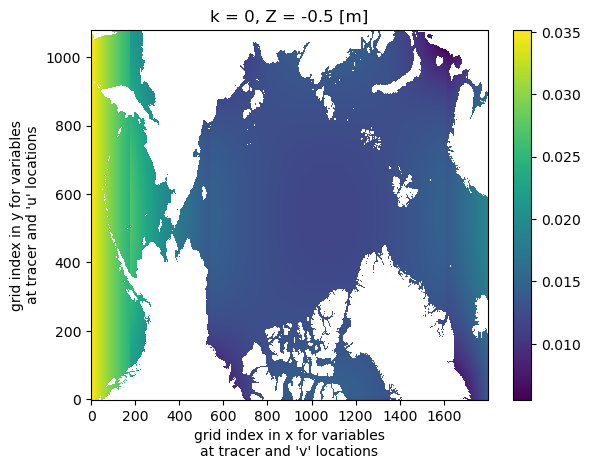

In [40]:
(vol_sassie.isel(k=0)/1e9).plot()

### Open 3D model fields

In [41]:
def get_aws_credentials(profile_name='sassie'):
    session = boto3.Session(profile_name=profile_name)
    credentials = session.get_credentials()

    # can print these to check keys but do not push to github
    #print("AWS_ACCESS_KEY_ID = {}".format(credentials.access_key))
    #print("AWS_SECRET_ACCESS_KEY = {}".format(credentials.secret_key))
    #print("AWS_SESSION_TOKEN = {}".format(credentials.token))

    return credentials

In [42]:
# load sassie profile credentials
aws_credentials = get_aws_credentials(profile_name='sassie')

In [43]:
# initialize s3 filesystem
s3_options = dict(anon=False, key=aws_credentials.access_key, secret=aws_credentials.secret_key)

In [44]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

In [45]:
# open ADVx_TH zarr store
# U Component Advective Flux of Potential Temperature (degC m^3/s)
ADVx_TH_zarr = open_zarr_store('s3://podaac-dev-sassie/ECCO_model/N1/V1R1/HH/ZARR/ADVx_TH_AVG_DAILY.ZARR/', s3_options)

# open ADVy_TH zarr store
# V Component Advective Flux of Potential Temperature (degC m^3/s)
ADVy_TH_zarr = open_zarr_store('s3://podaac-dev-sassie/ECCO_model/N1/V1R1/HH/ZARR/ADVy_TH_AVG_DAILY.ZARR/', s3_options)

# open ADVr_TH zarr store
# Vertical Advective Flux of Potential Temperature (degC m^3/s)
ADVr_TH_zarr = open_zarr_store('s3://podaac-dev-sassie/ECCO_model/N1/V1R1/HH/ZARR/ADVr_TH_AVG_DAILY.ZARR/', s3_options)

# open DFrE_TH zarr store
# Vertical Diffusive Flux of Potential Temperature (Explicit part) (degC m^3/s)
DFrE_TH_zarr = open_zarr_store('s3://podaac-dev-sassie/ECCO_model/N1/V1R1/HH/ZARR/DFrE_TH_AVG_DAILY.ZARR/', s3_options)

# open DFrI_TH zarr store
# Vertical Diffusive Flux of Potential Temperature (Implicit part) (degC m^3/s) 
DFrI_TH_zarr = open_zarr_store('s3://podaac-dev-sassie/ECCO_model/N1/V1R1/HH/ZARR/DFrI_TH_AVG_DAILY.ZARR/', s3_options)

# open TFLUX zarr store
# Total heat flux (match heat-content variations) (W/m^2)
TFLUX_zarr = open_zarr_store('s3://podaac-dev-sassie/ECCO_model/N1/V1R1/HH/ZARR/TFLUX_AVG_DAILY.ZARR/', s3_options)

# open oceQsw zarr store
# net Short-Wave radiation (+=down) (W/m^2)
oceQsw_zarr = open_zarr_store('s3://podaac-dev-sassie/ECCO_model/N1/V1R1/HH/ZARR/oceQsw_AVG_DAILY.ZARR/', s3_options)

# open oceQnet zarr store
# net heat flux into the ocean surface (+=down) (W/m^2)
oceQnet_zarr = open_zarr_store('s3://podaac-dev-sassie/ECCO_model/N1/V1R1/HH/ZARR/oceQnet_AVG_DAILY.ZARR/', s3_options)

In [ ]:
# open SALT zarr store
SALT_zarr = open_zarr_store('s3://podaac-dev-sassie/ECCO_model/N1/V1R1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

### Select one 25 day period for each of the model granules between snapshots

In [46]:
# select days between pickup file dates
ADVx_TH_slice = ADVx_TH_zarr.sel(time=slice(etan_monthly_snaps.time.values[0], etan_monthly_snaps.time.values[1]))
ADVy_TH_slice = ADVy_TH_zarr.sel(time=slice(etan_monthly_snaps.time.values[0], etan_monthly_snaps.time.values[1]))
ADVr_TH_slice = ADVr_TH_zarr.sel(time=slice(etan_monthly_snaps.time.values[0], etan_monthly_snaps.time.values[1]))
DFrE_TH_slice = DFrE_TH_zarr.sel(time=slice(etan_monthly_snaps.time.values[0], etan_monthly_snaps.time.values[1]))
DFrI_TH_slice = DFrI_TH_zarr.sel(time=slice(etan_monthly_snaps.time.values[0], etan_monthly_snaps.time.values[1]))
TFLUX_slice   = TFLUX_zarr.sel(time=slice(etan_monthly_snaps.time.values[0], etan_monthly_snaps.time.values[1]))
oceQsw_slice  = oceQsw_zarr.sel(time=slice(etan_monthly_snaps.time.values[0], etan_monthly_snaps.time.values[1]))

In [47]:
# double check dates
print(f"snapshot start and end: {theta_monthly_snaps.time.values[0:2]}")
print(f"\ntheta start: {TFLUX_slice.time.values[0]}")
print(f"theta end:   {TFLUX_slice.time.values[-1]}")

snapshot start and end: ['2014-03-06T00:00:00.000000000' '2014-03-31T00:00:00.000000000']

theta start: 2014-03-06T12:00:00.000000000
theta end:   2014-03-30T12:00:00.000000000


In [48]:
# take mean for single 25 day slice: 2014-06 to 2014-30
ADVx_TH_slice_mean = ADVx_TH_slice.ADVx_TH.mean('time').compute()
ADVy_TH_slice_mean = ADVy_TH_slice.ADVy_TH.mean('time').compute()
ADVr_TH_slice_mean = ADVr_TH_slice.ADVr_TH.mean('time').compute()
DFrE_TH_slice_mean = DFrE_TH_slice.DFrE_TH.mean('time').compute()
DFrI_TH_slice_mean = DFrI_TH_slice.DFrI_TH.mean('time').compute()
TFLUX_slice_mean   = TFLUX_slice.TFLUX.mean('time').compute()
oceQsw_slice_mean  = oceQsw_slice.oceQsw.mean('time').compute()

***

# Calculate total tendency of $\theta$ ($G^{\theta}_\textrm{total}$)

We calculate the monthly-averaged time tendency of ``THETA`` by differencing monthly ``THETA`` snapshots. Remember  that we need to include a scaling factor due to the nonlinear free surface formulation. Thus, we need to use snapshots of both `ETAN` and `THETA`  to evaluate $s^*\theta$.

### v4r4

In [49]:
grid = ecco.get_llc_grid(ds)

In [50]:
pprint(ds.time.values)
pprint(ds.time_snp.values)

array(['2014-01-16T12:00:00.000000000', '2014-02-15T00:00:00.000000000',
       '2014-03-16T12:00:00.000000000', '2014-04-16T00:00:00.000000000',
       '2014-05-16T12:00:00.000000000', '2014-06-16T00:00:00.000000000',
       '2014-07-16T12:00:00.000000000', '2014-08-16T12:00:00.000000000',
       '2014-09-16T00:00:00.000000000', '2014-10-16T12:00:00.000000000',
       '2014-11-16T00:00:00.000000000', '2014-12-16T12:00:00.000000000'],
      dtype='datetime64[ns]')
array(['2014-01-01T00:00:00.000000000', '2014-02-01T00:00:00.000000000',
       '2014-03-01T00:00:00.000000000', '2014-04-01T00:00:00.000000000',
       '2014-05-01T00:00:00.000000000', '2014-06-01T00:00:00.000000000',
       '2014-07-01T00:00:00.000000000', '2014-08-01T00:00:00.000000000',
       '2014-09-01T00:00:00.000000000', '2014-10-01T00:00:00.000000000',
       '2014-11-01T00:00:00.000000000', '2014-12-01T00:00:00.000000000',
       '2015-01-01T00:00:00.000000000'], dtype='datetime64[ns]')


In [51]:
# Calculate the s*theta term
credentials = update_credential(credentials)
sTHETA_ecco = ds.THETA_snp*(1+ds.ETAN_snp/ecco_grid.Depth)

... not updating credentials, 3303.071337s remaining


In [52]:
credentials = update_credential(credentials)
# Total tendency (degC/s)
G_total_ecco_globe = sTHETA_ecco.diff(dim='time_snp')/np.expand_dims(delta_t.values,axis=(1,2,3,4))

# re-assign and rename time coordinate
# -- time of G_total is at the end of the averaging period
G_total_ecco_globe = G_total_ecco_globe.rename({'time_snp':'time'})
G_total_ecco_globe = G_total_ecco_globe.assign_coords({'time':delta_t.time.values})

... not updating credentials, 3300.258215s remaining


In [53]:
G_total_ecco = G_total_ecco_globe.isel(time=2,tile=6).compute()

### HH

In [54]:
# Calculate the s*theta term
# sTHETA = theta_monthly_snaps.THETA*(1+etan_monthly_snaps.ETAN/HH_grid.Depth)

# Set eta term to zero
sTHETA = theta_monthly_snaps.THETA

In [55]:
# Total tendency (degC/s)
G_total_diff = sTHETA.diff(dim='time').isel(time=0)
G_total_diff.name = 'G_total'

Now convert $\Delta$ `THETA` / $\Delta$ t (month) to $\Delta$ `THETA` / $\Delta$ t (seconds) by dividing by the number of seconds in each month.

In [56]:
# calculate number of seconds over 25 days
secs_per_snap = 3600*24*25
print(secs_per_snap)

2160000


In [57]:
# Total tendency
G_total_sassie = G_total_diff / secs_per_snap

### compare for surface (k=0)

In [58]:
# cut out section of SASSIE model and rotate to match ECCO v4r4 Arctic tile
G_total_sassie_surf = G_total_sassie.isel(k=0,i=slice(500,1600))
G_total_sassie_surf_rot = np.rot90(G_total_sassie_surf,2)
G_total_sassie_surf.values = G_total_sassie_surf_rot

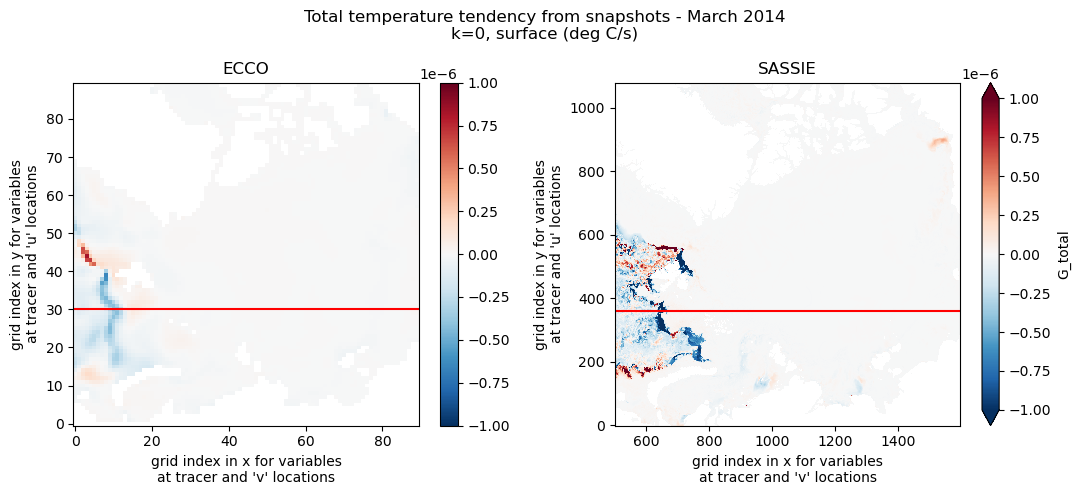

In [59]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[11,5])
G_total_ecco.sel(k=0).plot(ax=ax1,cmap='RdBu_r',vmin=-1e-6,vmax=1e-6);
G_total_sassie_surf.plot(ax=ax2,cmap='RdBu_r',vmin=-1e-6,vmax=1e-6);
ax1.set_title("ECCO")
ax2.set_title("SASSIE");
plt.suptitle("Total temperature tendency from snapshots - March 2014\nk=0, surface (deg C/s)")
ax1.axhline(y=30,color='r')
ax2.axhline(y=360,color='r')
plt.tight_layout()

### plot magnitudes from horizontal line shown above (red)

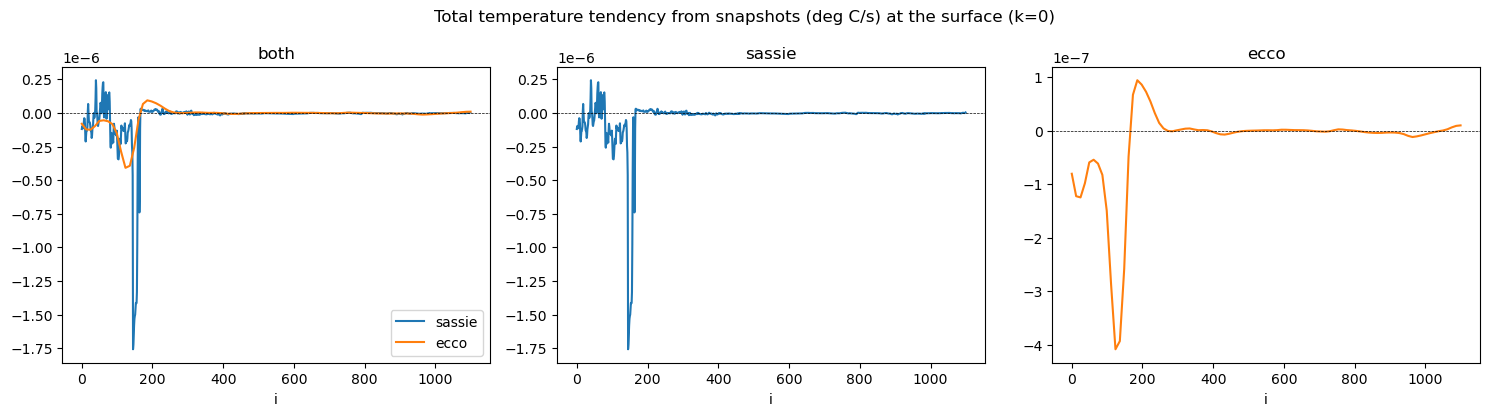

In [60]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[15,4])

ax1.set_title('both')
ax1.plot(G_total_sassie_surf.isel(j=360),label='sassie')
ax1.plot(np.linspace(0,1100,90),G_total_ecco.isel(k=0,j=30),label='ecco')

plt.suptitle('Total temperature tendency from snapshots (deg C/s) at the surface (k=0)')
ax1.legend()

ax2.set_title('sassie')
ax2.plot(G_total_sassie_surf.isel(j=360),label='sassie')

ax3.set_title('ecco')
ax3.plot(np.linspace(0,1100,90),G_total_ecco.isel(k=0,j=30),label='ecco',c='tab:orange');
plt.tight_layout()

for ax in (ax1,ax2,ax3):
    ax.set_xlabel("i")
    ax.axhline(y=0,color='k',linewidth=0.5,linestyle='dashed');

### compare for ~55 m

In [61]:
G_total_sassie_55 = G_total_sassie.isel(k=16,i=slice(500,1600))
G_total_sassie_55_rot = np.rot90(G_total_sassie_55,2)
G_total_sassie_55.values = G_total_sassie_55_rot

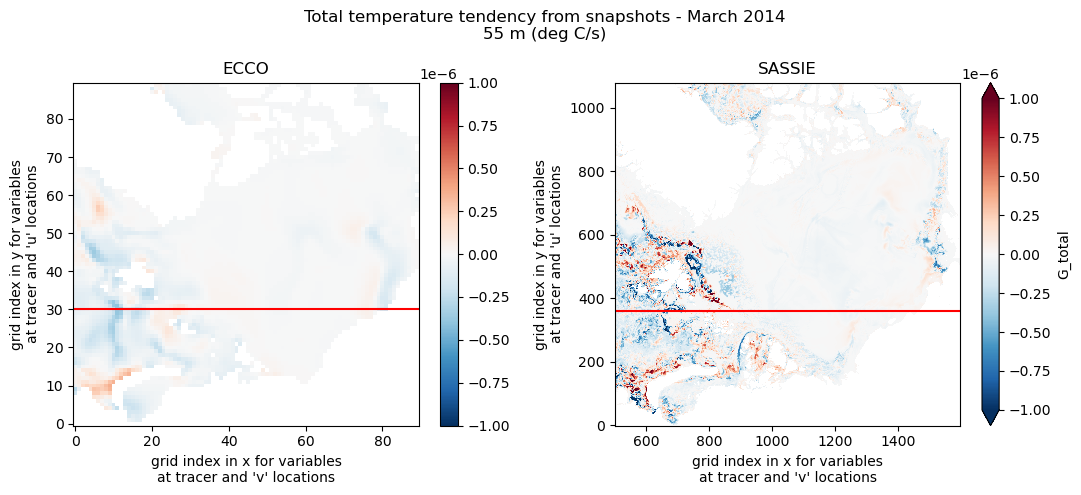

In [62]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[11,5])
G_total_ecco.sel(k=5).plot(ax=ax1,cmap='RdBu_r',vmin=-1e-6,vmax=1e-6);
G_total_sassie_55.plot(ax=ax2,cmap='RdBu_r',vmin=-1e-6,vmax=1e-6);
ax1.set_title("ECCO")
ax2.set_title("SASSIE");
plt.suptitle("Total temperature tendency from snapshots - March 2014\n55 m (deg C/s)")
ax1.axhline(y=30,color='r')
ax2.axhline(y=360,color='r')
plt.tight_layout()

### plot magnitudes from horizontal line shown above (red)

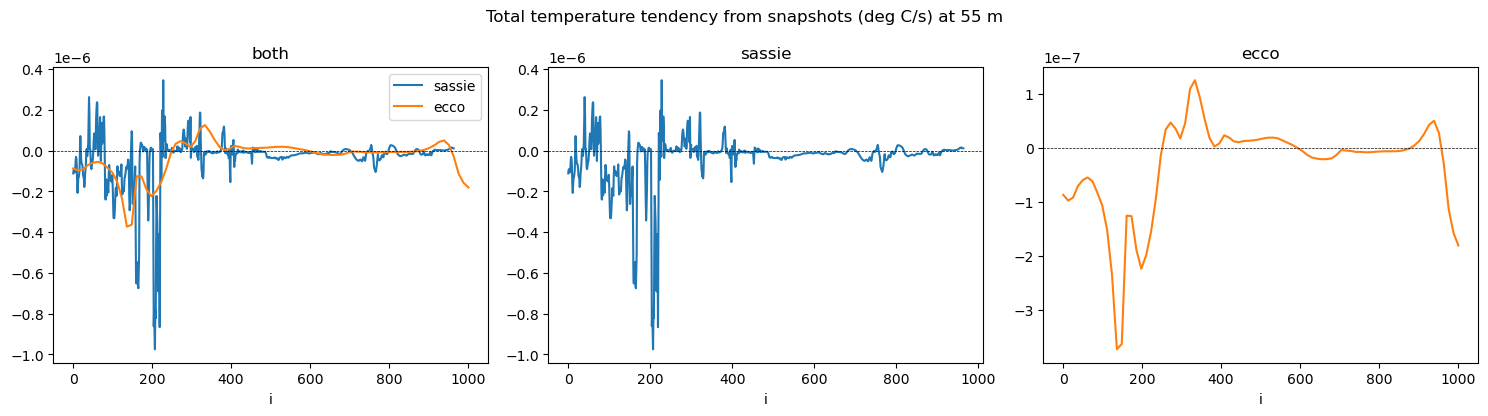

In [63]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[15,4])

ax1.set_title('both')
ax1.plot(G_total_sassie_55.isel(j=360),label='sassie')
ax1.plot(np.linspace(0,1100,90),G_total_ecco.isel(k=5,j=30),label='ecco')

plt.suptitle('Total temperature tendency from snapshots (deg C/s) at 55 m')
ax1.legend()

ax2.set_title('sassie')
ax2.plot(G_total_sassie_55.isel(j=360),label='sassie')

ax3.set_title('ecco')
ax3.plot(np.linspace(0,1100,90),G_total_ecco.isel(k=5,j=30),label='ecco',c='tab:orange');
plt.tight_layout()

for ax in (ax1,ax2,ax3):
    ax.set_xlabel("i")
    ax.axhline(y=0,color='k',linewidth=0.5,linestyle='dashed');

# Calculate tendency due to advective convergence ($G^{\theta}_\textrm{advection}$)
### Horizontal convergence of advective heat flux
The relevant fields from the diagnostic output here are
- `ADVx_TH`: U Component Advective Flux of Potential Temperature (degC m^3/s)
- `ADVy_TH`: V Component Advective Flux of Potential Temperature (degC m^3/s)

### ecco

In [64]:
def diff_2d_flux(flux_vector_dict):
    """
    A function (similar to xgcm.Grid.diff_2d_vector) that differences flux variables on the HH Arctic grid.
    """

    u_flux = flux_vector_dict['X']
    v_flux = flux_vector_dict['Y']

    u_flux_padded = u_flux.pad(pad_width={'i_g':(0,1)},mode='constant',constant_values=np.nan)
    v_flux_padded = v_flux.pad(pad_width={'j_g':(0,1)},mode='constant',constant_values=np.nan)

    # take differences
    diff_u_flux = u_flux_padded.diff('i_g')
    diff_v_flux = v_flux_padded.diff('j_g')

    # include coordinates of input DataArrays and correct dimension/coordinate names
    diff_u_flux = diff_u_flux.assign_coords(u_flux.coords).rename({'i_g':'i'})
    diff_v_flux = diff_v_flux.assign_coords(v_flux.coords).rename({'j_g':'j'})

    diff_flux_vector_dict = {'X':diff_u_flux,'Y':diff_v_flux}

    return diff_flux_vector_dict

In [65]:
# Set fluxes on land to zero (instead of NaN)
ds['ADVx_TH'] = ds.ADVx_TH.where(ecco_grid.hFacW.values > 0,0)
ds['ADVy_TH'] = ds.ADVy_TH.where(ecco_grid.hFacS.values > 0,0)

# Difference of horizontal components of divergence
ADVxy_diff_ecco = diff_2d_flux({'X': ds.isel(tile=6,time=2).ADVx_TH.load(), \
                                'Y': ds.isel(tile=6,time=2).ADVy_TH.load()})

In [66]:
vol_arctic = vol_ecco.isel(tile=6).where(ecco_grid.maskC.isel(tile=6),np.nan)

In [67]:
# Convergence of horizontal advection (degC m^3/s)
adv_hConvH_ecco_m3 = (-(ADVxy_diff_ecco['X'] + ADVxy_diff_ecco['Y']))

# divide by volume to get degC/s
adv_hConvH_ecco = adv_hConvH_ecco_m3 / vol_arctic

### sassie

In [68]:
def diff_2d_flux_HH(flux_vector_dict):
    """
    A function (similar to xgcm.Grid.diff_2d_vector) that differences flux variables on the HH Arctic grid.
    """

    u_flux = flux_vector_dict['X']
    v_flux = flux_vector_dict['Y']

    # take differences
    diff_u_flux = u_flux.diff('i_g')
    diff_v_flux = v_flux.diff('j_g')
    
    diff_u_flux_padded = diff_u_flux.pad(pad_width={'i_g':(1,0)},mode='constant',constant_values=np.nan)
    diff_v_flux_padded = diff_v_flux.pad(pad_width={'j_g':(1,0)},mode='constant',constant_values=np.nan)

    # include coordinates of input DataArrays and correct dimension/coordinate names
    diff_u_flux = diff_u_flux_padded.assign_coords(u_flux.coords).rename({'i_g':'i'})
    diff_v_flux = diff_v_flux_padded.assign_coords(v_flux.coords).rename({'j_g':'j'})

    diff_flux_vector_dict = {'X':diff_u_flux,'Y':diff_v_flux}

    return diff_flux_vector_dict

In [69]:
# Set fluxes on land to zero (instead of NaN)
ADVx_TH_sassie = ADVx_TH_slice_mean.where(HH_grid.hFacW.values > 0,0)
ADVy_TH_sassie = ADVy_TH_slice_mean.where(HH_grid.hFacS.values > 0,0)

# Difference of horizontal components of divergence
ADVxy_diff_sassie = diff_2d_flux_HH({'X': ADVx_TH_sassie.load(), \
                                     'Y': ADVy_TH_sassie.load()})

In [70]:
# Convergence of horizontal advection (degC m^3/s)
adv_hConvH_sassie_m3 = (-(ADVxy_diff_sassie['X'] + ADVxy_diff_sassie['Y']))

# divide by volume to get degC/s
adv_hConvH_sassie = adv_hConvH_sassie_m3 / vol_sassie

### compare horizontal convergence at the surface

In [71]:
adv_hConvH_sassie_surf = adv_hConvH_sassie.isel(k=0,i=slice(500,1600))
adv_hConvH_sassie_surf_rot = np.rot90(adv_hConvH_sassie_surf,2)
adv_hConvH_sassie_surf.values = adv_hConvH_sassie_surf_rot

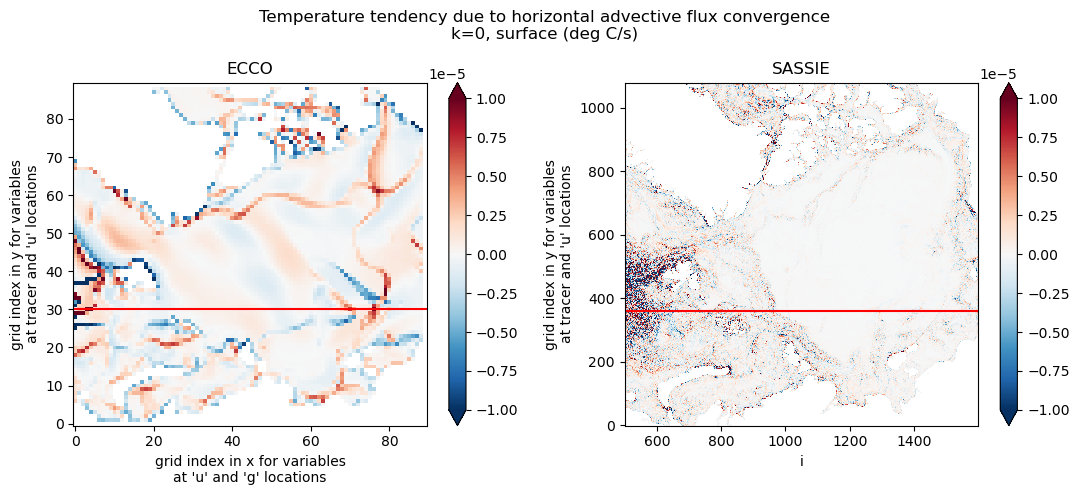

In [72]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[11,5])
adv_hConvH_ecco.isel(k=0).plot(ax=ax1,cmap='RdBu_r',vmin=-1e-5,vmax=1e-5);
adv_hConvH_sassie_surf.plot(ax=ax2,cmap='RdBu_r',vmin=-1e-5,vmax=1e-5);
ax1.set_title("ECCO")
ax2.set_title("SASSIE");
plt.suptitle("Temperature tendency due to horizontal advective flux convergence\nk=0, surface (deg C/s)")
ax1.axhline(y=30,color='r')
ax2.axhline(y=360,color='r')
plt.tight_layout()

### plot magnitudes from horizontal line shown above (red)

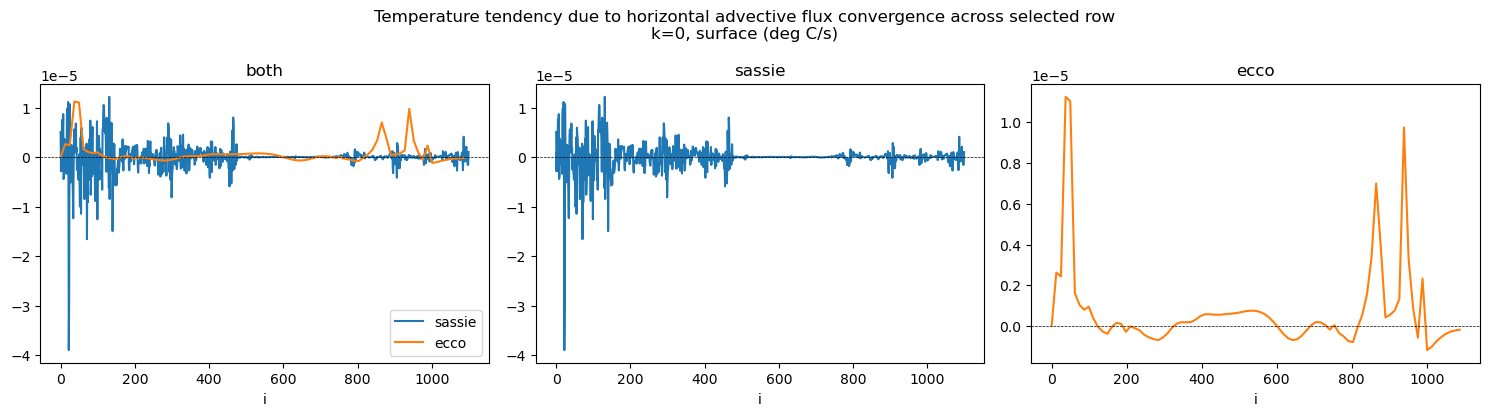

In [73]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[15,4])

ax1.set_title('both')
ax1.plot(adv_hConvH_sassie_surf.isel(j=360),label='sassie')
ax1.plot(np.linspace(0,1100,90),adv_hConvH_ecco.isel(k=0).isel(j=30),label='ecco')

plt.suptitle('Temperature tendency due to horizontal advective flux convergence across selected row\nk=0, surface (deg C/s)')
ax1.legend()

ax2.set_title('sassie')
ax2.plot(adv_hConvH_sassie_surf.isel(j=360),label='sassie')

ax3.set_title('ecco')
ax3.plot(np.linspace(0,1100,90),adv_hConvH_ecco.isel(k=0).isel(j=30),label='ecco',c='tab:orange');
plt.tight_layout()

for ax in (ax1,ax2,ax3):
    ax.set_xlabel("i")
    ax.axhline(y=0,color='k',linewidth=0.5,linestyle='dashed');

### Vertical convergence of advective heat flux
The relevant field from the diagnostic output is
- `ADVr_TH`: Vertical Advective Flux of Potential Temperature (degC m^3/s)

### ecco

In [74]:
# Set fluxes on land to zero (instead of NaN)
ds['ADVr_TH'] = ds.ADVr_TH.where(ecco_grid.hFacC.values > 0,0)

# Load monthly averages of vertical advective flux
ADVr_TH_ecco = ds.ADVr_TH.transpose('time','tile','k_l','j','i')

In [75]:
# Pad the bottom
ADVr_TH_ecco_padded = ADVr_TH_ecco.pad(pad_width={'k_l':(0,1)},mode='constant',constant_values=np.nan)

In [76]:
# check padding
# ADVr_TH_ecco_padded.isel(k_l=-1,i=0,tile=6).values

In [77]:
# Take differences to get convergence of vertical advection (degC m^3/s)
ADVz_diff_ecco = ADVr_TH_ecco_padded.diff('k_l').compute()

In [78]:
# change dim name
adv_vert_convergence_ecco = ADVz_diff_ecco.assign_coords(ADVr_TH_ecco.coords).rename({'k_l':'k'})

# divide by vol to get degC/s
adv_vert_div_ecco = (adv_vert_convergence_ecco/vol_ecco).isel(time=2, tile=6).compute()

### sassie

In [79]:
# Pad the bottom
ADVr_TH_padded_sassie = ADVr_TH_slice_mean.pad(pad_width={'k_l':(0,1)},mode='constant',constant_values=np.nan)

In [80]:
# check padding
# ADVr_TH_padded_sassie.isel(k_l=-1,i=0).values

In [81]:
# Take differences to get convergence of vertical advection (degC m^3/s)
ADVz_diff_sassie = ADVr_TH_padded_sassie.diff('k_l').compute()

In [82]:
# change dim name
adv_vert_convergence_sassie = ADVz_diff_sassie.assign_coords(ADVr_TH_slice_mean.coords).rename({'k_l':'k'})

# divide by vol to get degC/s
adv_vert_div_sassie = (adv_vert_convergence_sassie/vol_sassie).compute()

### compare at surface

In [83]:
adv_vert_div_sassie_surf = adv_vert_div_sassie.isel(k=0,i=slice(500,1600))
adv_vert_div_sassie_surf_rot = np.rot90(adv_vert_div_sassie_surf,2)
adv_vert_div_sassie_surf.values = adv_vert_div_sassie_surf_rot

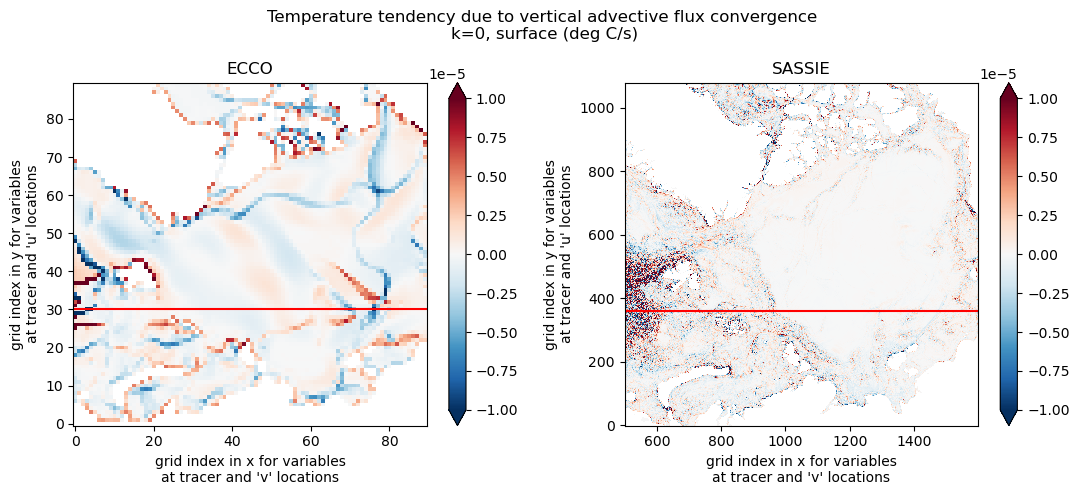

In [84]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[11,5])
adv_vert_div_ecco.isel(k=0).plot(ax=ax1,cmap='RdBu_r',vmin=-1e-5,vmax=1e-5);
adv_vert_div_sassie_surf.plot(ax=ax2,cmap='RdBu_r',vmin=-1e-5,vmax=1e-5);
ax1.set_title("ECCO")
ax2.set_title("SASSIE");
plt.suptitle("Temperature tendency due to vertical advective flux convergence \nk=0, surface (deg C/s)")
ax1.axhline(y=30,color='r')
ax2.axhline(y=360,color='r')
plt.tight_layout()

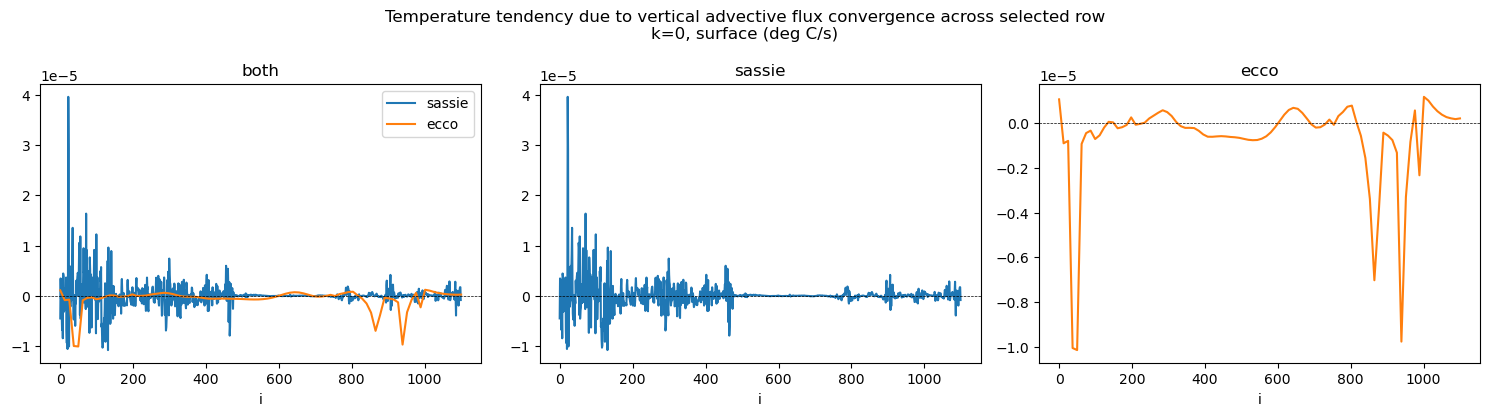

In [85]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[15,4])

ax1.set_title('both')
ax1.plot(adv_vert_div_sassie_surf.isel(j=360),label='sassie')
ax1.plot(np.linspace(0,1100,90),adv_vert_div_ecco.isel(k=0,j=30),label='ecco')

plt.suptitle('Temperature tendency due to vertical advective flux convergence across selected row\nk=0, surface (deg C/s)')
ax1.legend()

ax2.set_title('sassie')
ax2.plot(adv_vert_div_sassie_surf.isel(j=360),label='sassie')

ax3.set_title('ecco')
ax3.plot(np.linspace(0,1100,90),adv_vert_div_ecco.isel(k=0,j=30),label='ecco',c='tab:orange');
plt.tight_layout()

for ax in (ax1,ax2,ax3):
    ax.set_xlabel("i")
    ax.axhline(y=0,color='k',linewidth=0.5,linestyle='dashed');

### Total convergence of advective flux ($G^{\theta}_\textrm{advection}$)
We can get the total convergence by simply adding the horizontal and vertical component. 

### ecco

In [86]:
# Sum horizontal and vertical convergences
G_advection_ecco = (adv_hConvH_ecco + adv_vert_div_ecco).compute()

### sassie

In [87]:
# Sum horizontal and vertical convergences
G_advection_sassie = (adv_hConvH_sassie + adv_vert_div_sassie).compute()

### compare

In [88]:
G_advection_sassie_surf = G_advection_sassie.isel(k=0,i=slice(500,1600))
G_advection_sassie_surf_rot = np.rot90(G_advection_sassie_surf,2)
G_advection_sassie_surf.values = G_advection_sassie_surf_rot

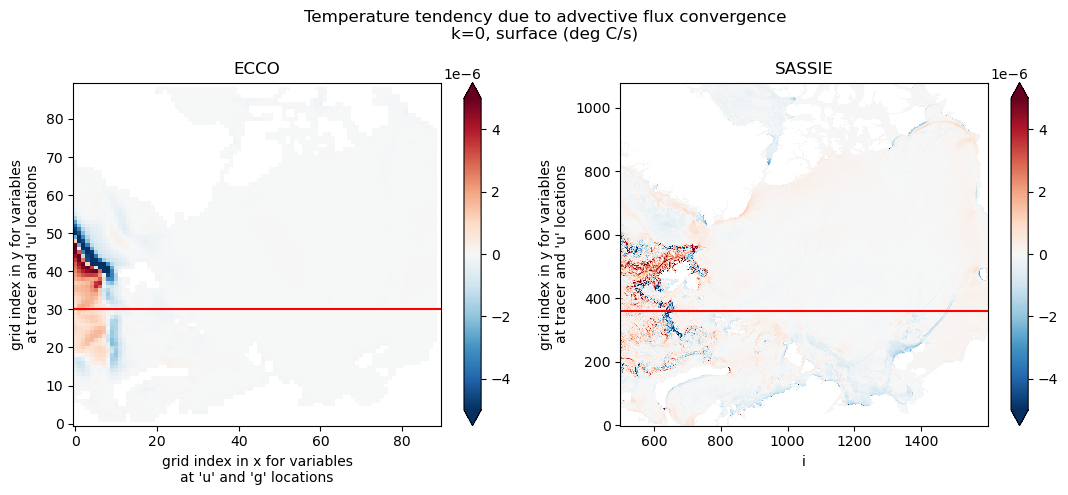

In [89]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[11,5])
G_advection_ecco.isel(k=0).plot(ax=ax1,cmap='RdBu_r',vmin=-5e-6,vmax=5e-6);
G_advection_sassie_surf.plot(ax=ax2,cmap='RdBu_r',vmin=-5e-6,vmax=5e-6);
ax1.set_title("Total advective flux convergence\nat the surface (deg C/s): ECCO")
ax2.set_title("Total advective flux convergence\nat the surface (deg C/s): SASSIE");
ax1.set_title("ECCO")
ax2.set_title("SASSIE");
plt.suptitle("Temperature tendency due to advective flux convergence\nk=0, surface (deg C/s)")
ax1.axhline(y=30,color='r')
ax2.axhline(y=360,color='r')
plt.tight_layout()

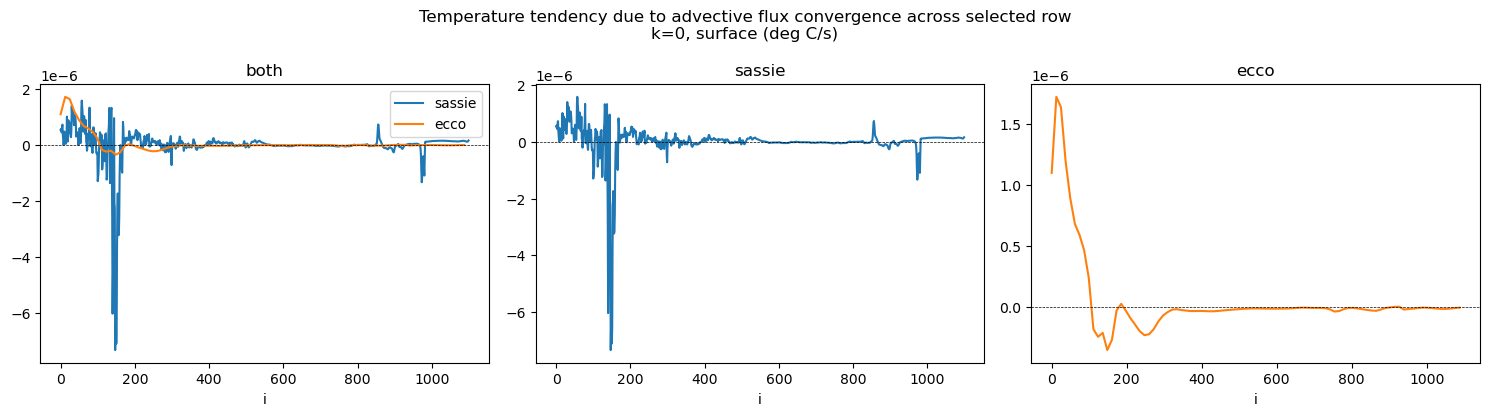

In [90]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[15,4])

ax1.set_title('both')
ax1.plot(G_advection_sassie_surf.isel(j=360),label='sassie')
ax1.plot(np.linspace(0,1100,90),G_advection_ecco.isel(k=0,j=30),label='ecco')

plt.suptitle('Temperature tendency due to advective flux convergence across selected row\nk=0, surface (deg C/s)')
ax1.legend()

ax2.set_title('sassie')
ax2.plot(G_advection_sassie_surf.isel(j=360),label='sassie')

ax3.set_title('ecco')
ax3.plot(np.linspace(0,1100,90),G_advection_ecco.isel(k=0,j=30),label='ecco',c='tab:orange');
plt.tight_layout()

for ax in (ax1,ax2,ax3):
    ax.set_xlabel("i")
    ax.axhline(y=0,color='k',linewidth=0.5,linestyle='dashed');

# Calculate tendency due to diffusive convergence ($G^{\theta}_\textrm{diffusion}$)
### Horizontal convergence of diffusive heat flux
The relevant fields from the diagnostic output here are
- `DFxE_TH`: U Component Diffusive Flux of Potential Temperature (degC m^3/s)
- `DFyE_TH`: V Component Diffusive Flux of Potential Temperature (degC m^3/s)

As with advective fluxes, we use the xgcm `grid` object to calculate the convergence of horizontal heat diffusion.

### ecco

In [91]:
# Set fluxes on land to zero (instead of NaN)
ds['DFxE_TH'] = ds.DFxE_TH.where(ecco_grid.hFacW.values > 0,0)
ds['DFyE_TH'] = ds.DFyE_TH.where(ecco_grid.hFacS.values > 0,0)

In [92]:
# Difference of horizontal components of divergence
DFxyE_diff_ecco = diff_2d_flux({'X': ds.isel(tile=6,time=2).DFxE_TH.load(), \
                                'Y': ds.isel(tile=6,time=2).DFyE_TH.load()})

In [93]:
vol_arctic = vol_ecco.isel(tile=6).where(ecco_grid.maskC.isel(tile=6),np.nan)

In [94]:
# Convergence of horizontal advection (degC m^3/s)
dif_hConvH_xy_ecco = (-(DFxyE_diff_ecco['X'] + DFxyE_diff_ecco['Y']))

In [95]:
# divide by vol to get degC/s
dif_hConvH_ecco = (dif_hConvH_xy_ecco/vol_arctic).compute()

### sassie

There is no horizontal diffusion for the sassie model

### Vertical convergence of diffusive heat flux
The relevant fields from the diagnostic output are
- `DFrE_TH`: Vertical Diffusive Flux of Potential Temperature (Explicit part) (degC m^3/s)
- `DFrI_TH`: Vertical Diffusive Flux of Potential Temperature (Implicit part) (degC m^3/s)
> **Note**: Vertical diffusion has both an explicit (`DFrE_TH`) and an implicit (`DFrI_TH`) part.

### ecco

In [96]:
# Set fluxes on land to zero (instead of NaN)
ds['DFrE_TH'] = ds.DFrE_TH.where(ecco_grid.hFacC.values > 0,0)
ds['DFrI_TH'] = ds.DFrI_TH.where(ecco_grid.hFacC.values > 0,0)

In [97]:
# Load monthly averages of vertical diffusive fluxes
DFrE_TH_ecco = ds.DFrE_TH.transpose('time','tile','k_l','j','i')
DFrI_TH_ecco = ds.DFrI_TH.transpose('time','tile','k_l','j','i')

In [98]:
# Pad the bottom
DFrE_TH_padded_ecco = DFrE_TH_ecco.pad(pad_width={'k_l':(0,1)},mode='constant',constant_values=np.nan)
DFrI_TH_padded_ecco = DFrI_TH_ecco.pad(pad_width={'k_l':(0,1)},mode='constant',constant_values=np.nan)

In [99]:
# check padding
# DFrE_TH_padded_ecco.isel(k_l=-1,i=0,tile=6).values
# DFrI_TH_padded_ecco.isel(k_l=-1,i=0,tile=6).values

In [100]:
# Take differences to get convergence of vertical advection (degC m^3/s)
DFrE_TH_diff_ecco = DFrE_TH_padded_ecco.diff('k_l').compute()
DFrI_TH_diff_ecco = DFrI_TH_padded_ecco.diff('k_l').compute()

In [101]:
# change dim name
difE_vert_convergence_ecco = DFrE_TH_diff_ecco.assign_coords(DFrE_TH_ecco.coords).rename({'k_l':'k'})
difI_vert_convergence_ecco = DFrI_TH_diff_ecco.assign_coords(DFrI_TH_ecco.coords).rename({'k_l':'k'})

# divide by vol to get degC/s
difE_vConvH_ecco = (difE_vert_convergence_ecco.isel(time=2,tile=6) / vol_arctic).compute()
difI_vConvH_ecco = (difI_vert_convergence_ecco.isel(time=2,tile=6) / vol_arctic).compute()

dif_vConvH_ecco = difE_vConvH_ecco + difI_vConvH_ecco

### sassie

In [102]:
# Set fluxes on land to zero (instead of NaN)
DFrE_TH_sassie = DFrE_TH_slice_mean.where(HH_grid.hFacC.values > 0,0)
DFrI_TH_sassie = DFrI_TH_slice_mean.where(HH_grid.hFacC.values > 0,0)

In [103]:
# Load monthly averages of vertical diffusive fluxes
DFrE_TH_sassie = DFrE_TH_sassie.transpose('k_l','j','i')
DFrI_TH_sassie = DFrI_TH_sassie.transpose('k_l','j','i')

In [104]:
# Pad the bottom
DFrE_TH_padded_sassie = DFrE_TH_sassie.pad(pad_width={'k_l':(0,1)},mode='constant',constant_values=np.nan)
DFrI_TH_padded_sassie = DFrI_TH_sassie.pad(pad_width={'k_l':(0,1)},mode='constant',constant_values=np.nan)

In [105]:
# check padding
# DFrE_TH_padded_sassie.isel(k_l=-1,i=0).values
# DFrI_TH_padded_sassie.isel(k_l=-1,i=0).values

In [106]:
# Take differences to get convergence of vertical advection (degC m^3/s)
DFrE_TH_diff_sassie = DFrE_TH_padded_sassie.diff('k_l').compute()
DFrI_TH_diff_sassie = DFrI_TH_padded_sassie.diff('k_l').compute()

In [107]:
# change dim name
difE_vert_convergence_sassie = DFrE_TH_diff_sassie.assign_coords(DFrE_TH_sassie.coords).rename({'k_l':'k'})
difI_vert_convergence_sassie = DFrI_TH_diff_sassie.assign_coords(DFrI_TH_sassie.coords).rename({'k_l':'k'})

# divide by vol to get degC/s
difE_vConvH_sassie = (difE_vert_convergence_sassie / vol_sassie).compute()
difI_vConvH_sassie = (difI_vert_convergence_sassie / vol_sassie).compute()

dif_vConvH_sassie = difE_vConvH_sassie + difI_vConvH_sassie

### Total convergence of diffusive flux ($G^{\theta}_\textrm{diffusion}$)

### ecco

In [108]:
# Sum horizontal and vertical convergences
G_diffusion_ecco = (dif_hConvH_ecco + dif_vConvH_ecco).compute()

### sassie

In [109]:
# for sassie, it is just vertical diffusion
G_diffusion_sassie = dif_vConvH_sassie

### compare

In [110]:
G_diffusion_sassie_surf = G_diffusion_sassie.isel(k=0,i=slice(500,1600))
G_diffusion_sassie_surf_rot = np.rot90(G_diffusion_sassie_surf,2)
G_diffusion_sassie_surf.values = G_diffusion_sassie_surf_rot

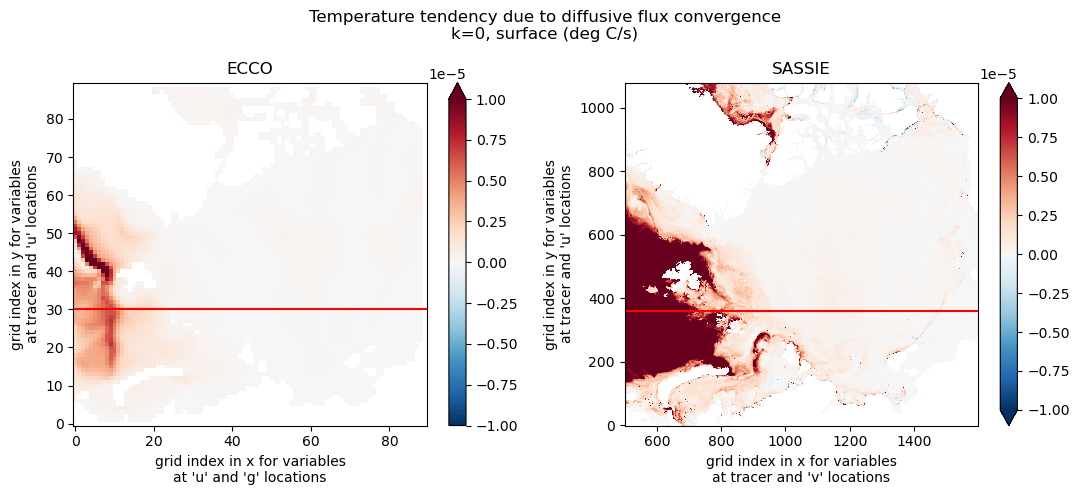

In [111]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[11,5])
G_diffusion_ecco.isel(k=0).plot(ax=ax1,cmap='RdBu_r',vmin=-1e-5,vmax=1e-5);
G_diffusion_sassie_surf.plot(ax=ax2,cmap='RdBu_r',vmin=-1e-5,vmax=1e-5);
ax1.set_title("ECCO")
ax2.set_title("SASSIE");
plt.suptitle("Temperature tendency due to diffusive flux convergence\nk=0, surface (deg C/s)")
ax1.axhline(y=30,color='r')
ax2.axhline(y=360,color='r')
plt.tight_layout()

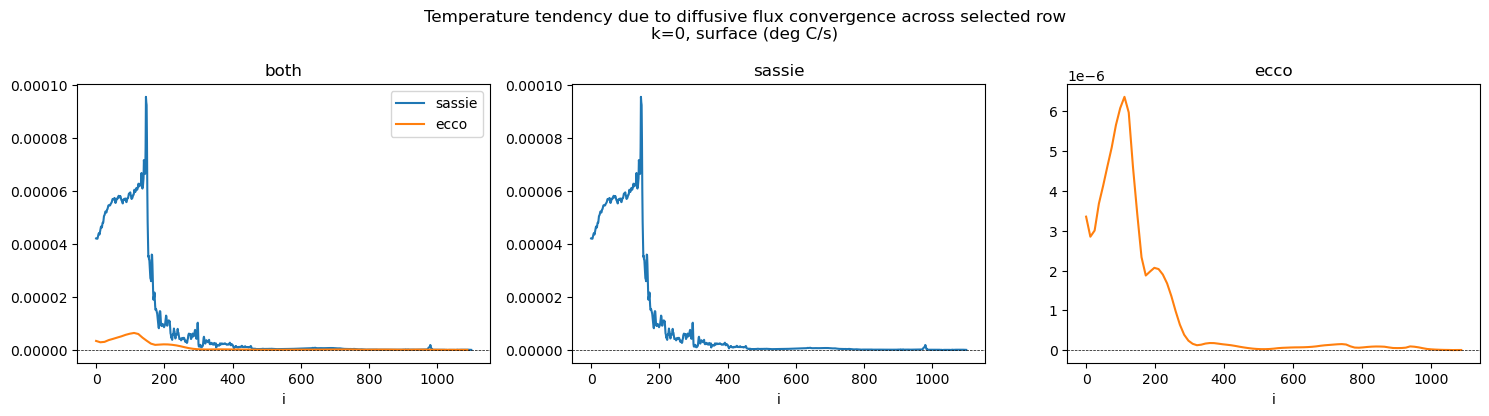

In [112]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[15,4])

ax1.set_title('both')
ax1.plot(G_diffusion_sassie_surf.isel(j=360),label='sassie')
ax1.plot(np.linspace(0,1100,90),G_diffusion_ecco.isel(k=0,j=30),label='ecco')

plt.suptitle('Temperature tendency due to diffusive flux convergence across selected row\nk=0, surface (deg C/s)')
ax1.legend()

ax2.set_title('sassie')
ax2.plot(G_diffusion_sassie_surf.isel(j=360),label='sassie')

ax3.set_title('ecco')
ax3.plot(np.linspace(0,1100,90),G_diffusion_ecco.isel(k=0,j=30),label='ecco',c='tab:orange');
plt.tight_layout()

for ax in (ax1,ax2,ax3):
    ax.set_xlabel("i")
    ax.axhline(y=0,color='k',linewidth=0.5,linestyle='dashed');

SASSIE ocean surface temperature tendency due to diffusive flux convergence is 10X larger than ECCO

# Calculate tendency due to forcing ($G^{\theta}_\textrm{forcing}$)
Finally, we evaluate the local forcing term due to surface heat and geothermal fluxes.

### Surface heat flux
For the surface contribution, there are two relevant model diagnostics:
- `TFLUX`: total heat flux (match heat-content variations) (W/m^2)
- `oceQsw`: net Short-Wave radiation (+=down) (W/m^2)

### ecco

Calculate surface heat penetration to get forcing for each vertical level

In [113]:
# Seawater density (kg/m^3)
rhoconst_ecco = 1029
## needed to convert surface mass fluxes to volume fluxes

# Heat capacity (J/kg/K)
c_p_ecco = 3994

# Constants for surface heat penetration (from Table 2 of Paulson and Simpson, 1977)
R = 0.62
zeta1 = 0.6
zeta2 = 20.0

In [114]:
Z = ecco_grid.Z.compute()
RF = np.concatenate([ecco_grid.Zp1.values[:-1],[np.nan]])

In [115]:
q1 = R*np.exp(1.0/zeta1*RF[:-1]) + (1.0-R)*np.exp(1.0/zeta2*RF[:-1])
q2 = R*np.exp(1.0/zeta1*RF[1:]) + (1.0-R)*np.exp(1.0/zeta2*RF[1:])

In [116]:
# Correction for the 200m cutoff
zCut = np.where(Z < -200)[0][0]
q1[zCut:] = 0
q2[zCut-1:] = 0

In [117]:
# Create xarray data arrays
q1 = xr.DataArray(q1,coords=[Z.k],dims=['k'])
q2 = xr.DataArray(q2,coords=[Z.k],dims=['k'])

In [118]:
## Land masks
# Make copy of hFacC
mskC = ecco_grid.hFacC.copy(deep=True).compute()

# Change all fractions (ocean) to 1. land = 0
mskC.values[mskC.values>0] = 1

In [119]:
# Shortwave flux below the surface (W/m^2)
forcH_subsurf_ecco = ((q1*(mskC==1)-q2*(mskC.shift(k=-1)==1))*ds.oceQsw).transpose('time','tile','k','j','i')

In [120]:
# Surface heat flux (W/m^2)
forcH_surf_ecco = ((ds.TFLUX - (1-(q1[0]-q2[0]))*ds.oceQsw)\
                   *mskC[0]).transpose('time','tile','j','i').assign_coords(k=0).expand_dims('k')

In [121]:
# Full-depth sea surface forcing (W/m^2)
forcH_ecco = xr.concat([forcH_surf_ecco,forcH_subsurf_ecco[:,:,1:]], dim='k').transpose('time','tile','k','j','i')

##### Geothermal flux

The geothermal flux contribution is not accounted for in any of the standard model diagnostics provided as output. Rather, this term, which is time invariant, is provided in the input file `geothermalFlux.bin` contained in the ancillary data archive. This archive can be downloaded from [PO.DAAC](https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/ECCO_L4_ANCILLARY_DATA_V4R4/ancillary_data_input_forcing_ECCO_V4r4.tar.gz), though accessing it there requires downloading a much larger tarball of files (~192 GB). So, for the time being, the `geothermalFlux.bin` file is also stored on the tutorial Github and can be downloaded [here](https://github.com/ECCO-GROUP/ECCO-v4-Python-Tutorial/raw/master/misc/geothermalFlux.bin).

> **Note**: The code cell below assumes `geothermalFlux.bin` has been placed in `~/Downloads` after downloading. Change the directory as needed.

In [122]:
# Load the geothermal heat flux using the routine 'read_llc_to_tiles'.
geoflx = ecco.read_llc_to_tiles(Path('/home/jpluser/git_repos/SASSIE_ECCO_exploratory/budgets/heat/v4r4_sassie/'), 'geothermalFlux.bin')

load_binary_array: loading file /home/jpluser/git_repos/SASSIE_ECCO_exploratory/budgets/heat/v4r4_sassie/geothermalFlux.bin
load_binary_array: data array shape  (1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4


The geothermal flux dataset needs to be saved as an xarray data array with the same format as the model output.

In [123]:
# Convert numpy array to an xarray DataArray with matching dimensions as the monthly mean fields
geoflx_llc = xr.DataArray(geoflx,coords={'tile': ecco_monthly_mean.tile.values,
                                         'j': ecco_monthly_mean.j.values,
                                         'i': ecco_monthly_mean.i.values},dims=['tile','j','i'])

Geothermal flux needs to be a three dimensional field since the sources are distributed along the ocean floor at various depths. This requires a three dimensional mask.

In [124]:
# Create 3d bathymetry mask
mskC_shifted = mskC.shift(k=-1)

mskC_shifted.values[-1,:,:,:] = 0
mskb = mskC - mskC_shifted

# Create 3d field of geothermal heat flux
geoflx3d = geoflx_llc * mskb.transpose('k','tile','j','i')
GEOFLX = geoflx3d.transpose('k','tile','j','i')
GEOFLX.attrs = {'standard_name': 'GEOFLX','long_name': 'Geothermal heat flux','units': 'W/m^2'}

### sassie

In [125]:
# Seawater density (kg/m^3)
# needed to convert surface mass fluxes to volume fluxes
rhoconst_sassie = 1027.5

# Heat capacity (J/(kg degC))
c_p_sassie = 3994

# Constants for surface heat penetration (from Table 2 of Paulson and Simpson, 1977)
R = 0.62
zeta1 = 0.6
zeta2 = 20.0

In [126]:
Z = HH_grid.Z.compute()
RF = np.concatenate([HH_grid.Zp1.values[:-1],[np.nan]])

In [127]:
q1 = R*np.exp(1.0/zeta1*RF[:-1]) + (1.0-R)*np.exp(1.0/zeta2*RF[:-1])
q2 = R*np.exp(1.0/zeta1*RF[1:]) + (1.0-R)*np.exp(1.0/zeta2*RF[1:])

In [128]:
# Correction for the 200m cutoff
zCut = np.where(Z < -200)[0][0]
q1[zCut:] = 0
q2[zCut-1:] = 0

In [129]:
# Create xarray data arrays
q1 = xr.DataArray(q1,coords=[Z.k],dims=['k'])
q2 = xr.DataArray(q2,coords=[Z.k],dims=['k'])

In [130]:
## Land masks
# Make copy of hFacC
mskC = HH_grid.hFacC.copy(deep=True).compute()

# Change all fractions (ocean) to 1. land = 0
mskC.values[mskC.values>0] = 1

In [131]:
# Shortwave flux below the surface (W/m^2)
forcH_subsurf_sassie = ((q1*(mskC==1)-q2*(mskC.shift(k=-1)==1))*oceQsw_slice_mean).transpose('k','j','i')

In [132]:
# Surface heat flux convergence into the uppermost grid cell (W/m^2)
forcH_surf_sassie = ((TFLUX_slice_mean - (1-(q1[0]-q2[0]))*oceQsw_slice_mean)\
                     *mskC[0]).transpose('j','i').assign_coords(k=0).expand_dims('k')

In [133]:
# Full-depth sea surface forcing (W/m^2)
forcH_sassie = xr.concat([forcH_surf_sassie,forcH_subsurf_sassie[1:,:,:]], dim='k').transpose('k','j','i')

### compare full-depth sea surface forcing in $Wm^{-2}$

In [134]:
forcH_sassie_surf = forcH_sassie.isel(k=0,i=slice(500,1600))
forcH_sassie_surf_rot = np.rot90(forcH_sassie_surf,2)
forcH_sassie_surf.values = forcH_sassie_surf_rot

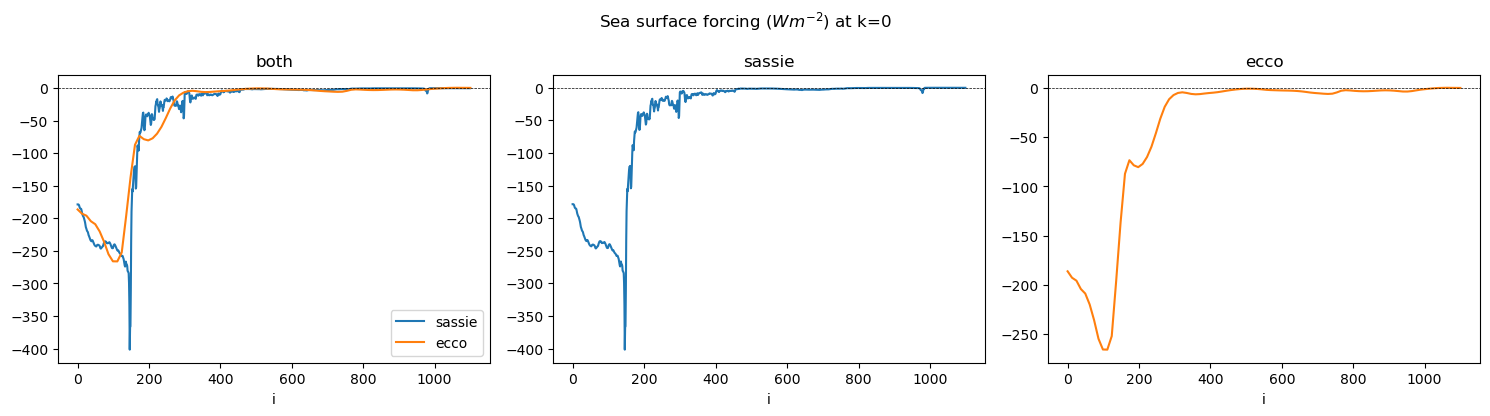

In [135]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[15,4])

ax1.set_title('both')
ax1.plot(forcH_sassie_surf.isel(j=360),label='sassie')
ax1.plot(np.linspace(0,1100,90),forcH_ecco.isel(k=0,j=30,time=2,tile=6),label='ecco')

plt.suptitle('Sea surface forcing ($Wm^{-2}$) at k=0')
ax1.legend()

ax2.set_title('sassie')
ax2.plot(forcH_sassie_surf.isel(j=360),label='sassie')

ax3.set_title('ecco')
ax3.plot(np.linspace(0,1100,90),forcH_ecco.isel(k=0,j=30,time=2,tile=6),label='ecco',c='tab:orange');
plt.tight_layout()

for ax in (ax1,ax2,ax3):
    ax.set_xlabel("i")
    ax.axhline(y=0,color='k',linewidth=0.5,linestyle='dashed');

### Total forcing ($G^{\theta}_\textrm{forcing}$)

### ecco

In [136]:
# Add geothermal heat flux to forcing field and convert from W/m^2 to degC/s
G_forcing_ecco = (((forcH_ecco + GEOFLX)/(rhoconst_ecco*c_p_ecco))/(ecco_grid.hFacC*ecco_grid.drF)).isel(tile=6,time=2).compute()

/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


**Units check:**<br>
cp = J/(K*kg)<br>
rho = kg/m^3


(W/m^2) / (kg/m^3) / (J/(K*kg)) / m = K/s<br>
where W = J / s

### sassie

In [137]:
# convert from W/m^2 to degC/s
G_forcing_sassie = ((forcH_sassie/(rhoconst_sassie*c_p_sassie))/(HH_grid.hFacC*HH_grid.drF)).compute()

### compare

In [138]:
G_forcing_sassie_surf = G_forcing_sassie.isel(k=0,i=slice(500,1600))
G_forcing_sassie_surf_rot = np.rot90(G_forcing_sassie_surf,2)
G_forcing_sassie_surf.values = G_forcing_sassie_surf_rot

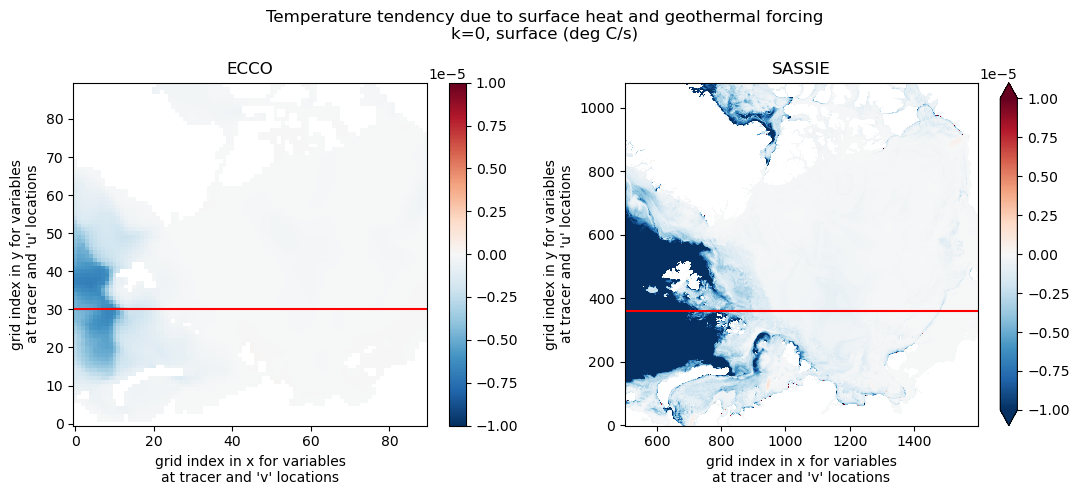

In [139]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[11,5])
G_forcing_ecco.isel(k=0).plot(ax=ax1,cmap='RdBu_r',vmin=-1e-5,vmax=1e-5);
G_forcing_sassie_surf.plot(ax=ax2,cmap='RdBu_r',vmin=-1e-5,vmax=1e-5);
ax1.set_title("G_forcing at the surface (degC/s): ECCO")
ax2.set_title("G_forcing at the surface (degC/s): SASSIE");
ax1.set_title("ECCO")
ax2.set_title("SASSIE");
plt.suptitle("Temperature tendency due to surface heat and geothermal forcing\nk=0, surface (deg C/s)")
ax1.axhline(y=30,color='r')
ax2.axhline(y=360,color='r')
plt.tight_layout()

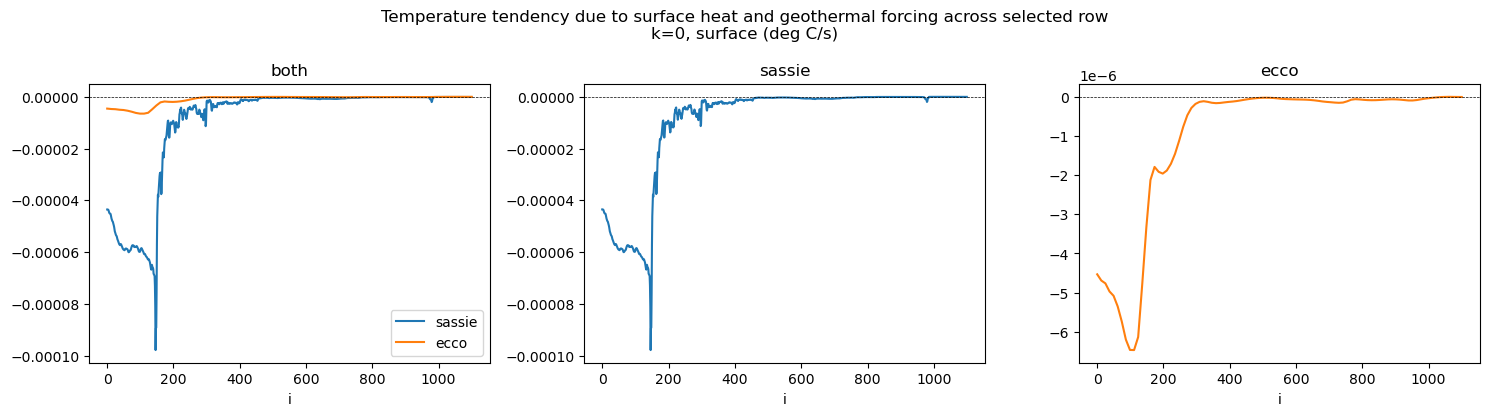

In [140]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[15,4])

ax1.set_title('both')
ax1.plot(G_forcing_sassie_surf.isel(j=360),label='sassie')
ax1.plot(np.linspace(0,1100,90),G_forcing_ecco.isel(k=0,j=30),label='ecco')

plt.suptitle('Temperature tendency due to surface heat and geothermal forcing across selected row\nk=0, surface (deg C/s)')
ax1.legend()

ax2.set_title('sassie')
ax2.plot(G_forcing_sassie_surf.isel(j=360),label='sassie')

ax3.set_title('ecco')
ax3.plot(np.linspace(0,1100,90),G_forcing_ecco.isel(k=0,j=30),label='ecco',c='tab:orange');
plt.tight_layout()

for ax in (ax1,ax2,ax3):
    ax.set_xlabel("i")
    ax.axhline(y=0,color='k',linewidth=0.5,linestyle='dashed');

Similar to the temperature tendency due to diffusive flux convergence plotted above, the SASSIE temperature tendency due surface heat forcing is 10X larger than ECCO for k=0

# Budget closure

### ecco

In [157]:
# Total convergence
ConvH_ecco = G_advection_ecco + G_diffusion_ecco

In [158]:
# Sum of terms in RHS of equation
rhs_ecco = ConvH_ecco + G_forcing_ecco

### sassie

In [159]:
# double check dims
print(G_advection_sassie.shape)
print(G_diffusion_sassie.shape)
print(G_forcing_sassie.shape)

(90, 1080, 1800)
(90, 1080, 1800)
(90, 1080, 1800)


In [160]:
# Total convergence
ConvH_sassie = G_advection_sassie + G_diffusion_sassie

In [161]:
# Sum of terms in RHS of equation
rhs_sassie = ConvH_sassie + G_forcing_sassie

### RHS

In [162]:
rhs_sassie_rot = rhs_sassie.isel(k=0,i=slice(500,1600))
sassie_rot90 = np.rot90(rhs_sassie_rot,2)
rhs_sassie_rot.values = sassie_rot90

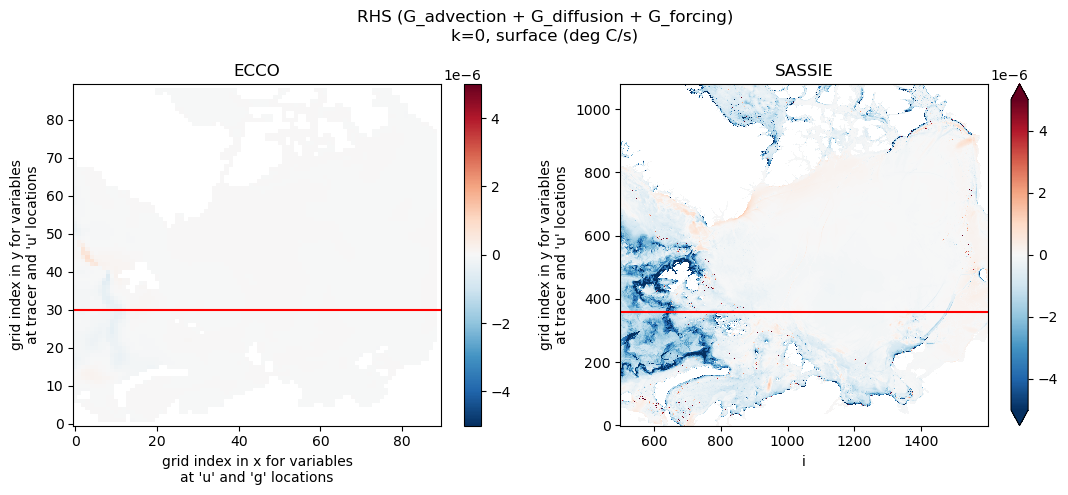

In [163]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[11,5])
rhs_ecco.isel(k=0).plot(ax=ax1,cmap='RdBu_r',vmin=-5e-6,vmax=5e-6);
rhs_sassie_rot.plot(ax=ax2,cmap='RdBu_r',vmin=-5e-6,vmax=5e-6);
ax1.set_title("RHS at the surface: ECCO (degC/s)")
ax2.set_title("RHS at the surface: SASSIE (degC/s)");
ax1.set_title("ECCO")
ax2.set_title("SASSIE");
plt.suptitle("RHS (G_advection + G_diffusion + G_forcing)\nk=0, surface (deg C/s)")
ax1.axhline(y=30,color='r')
ax2.axhline(y=360,color='r')
plt.tight_layout()

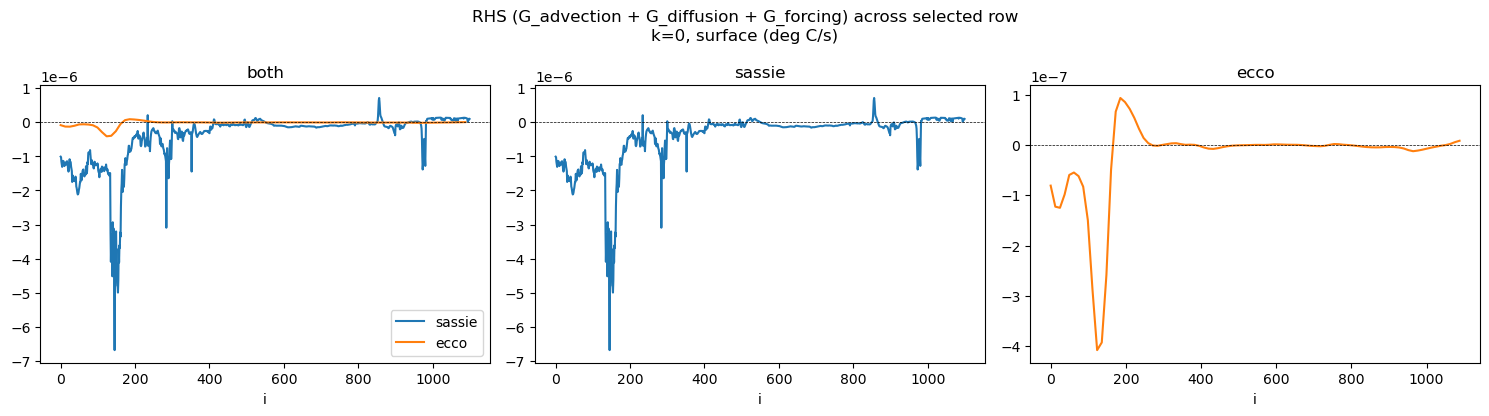

In [164]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[15,4])

ax1.set_title('both')
ax1.plot(rhs_sassie_rot.isel(j=360),label='sassie')
ax1.plot(np.linspace(0,1100,90),rhs_ecco.isel(k=0,j=30),label='ecco')

plt.suptitle('RHS (G_advection + G_diffusion + G_forcing) across selected row\nk=0, surface (deg C/s)')
ax1.legend()

ax2.set_title('sassie')
ax2.plot(rhs_sassie_rot.isel(j=360),label='sassie')

ax3.set_title('ecco')
ax3.plot(np.linspace(0,1100,90),rhs_ecco.isel(k=0,j=30),label='ecco',c='tab:orange');
plt.tight_layout()

for ax in (ax1,ax2,ax3):
    ax.set_xlabel("i")
    ax.axhline(y=0,color='k',linewidth=0.5,linestyle='dashed');

## Residuals

In [165]:
# pad edges of v4r4 to match rhs (this is due to diffusive and advective flux convergence calculations where we end up with [n-1] rows and cols)
G_total_pad = G_total_ecco.copy()
G_total_pad[:,:,-1] = np.nan
G_total_pad[:,-1,:] = np.nan

In [166]:
print(rhs_ecco.shape)
print(G_total_pad.shape)
print(rhs_sassie.shape)
print(G_total_sassie.shape)

(50, 90, 90)
(50, 90, 90)
(90, 1080, 1800)
(90, 1080, 1800)


In [167]:
# calculate residuals across all vertical levels
res_ecco = (rhs_ecco-G_total_pad).compute()
res_sassie = (rhs_sassie-G_total_sassie).compute()

### Plot SASSIE residuals at the surface

Colored points mark locations for vertical profiles plotted below

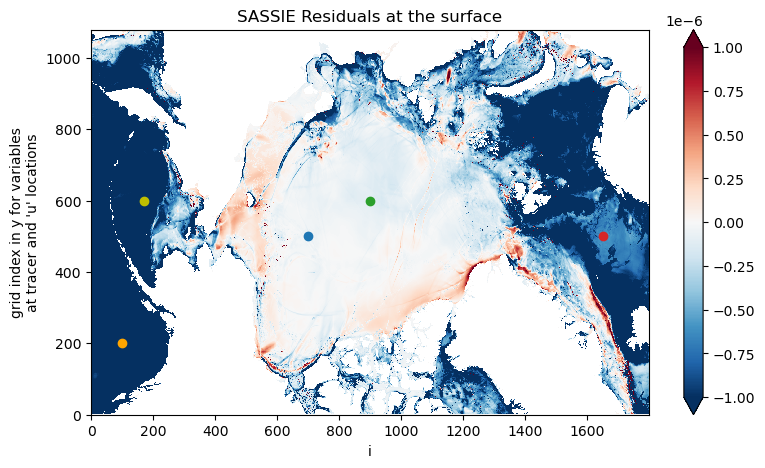

In [168]:
res_sassie.isel(k=0).plot(cmap='RdBu_r',vmin=-1e-6,vmax=1e-6,figsize=[9,5]);

# add points for locations where vertical profiles were plotted below
plt.scatter(900,600,c='tab:green');
plt.scatter(700,500,c='tab:blue');
plt.scatter(170,600,c='y');
plt.scatter(100,200,c='orange');
plt.scatter(1650,500,c='tab:red');
plt.title("SASSIE Residuals at the surface");

### Plot SASSIE residuals at 250 m

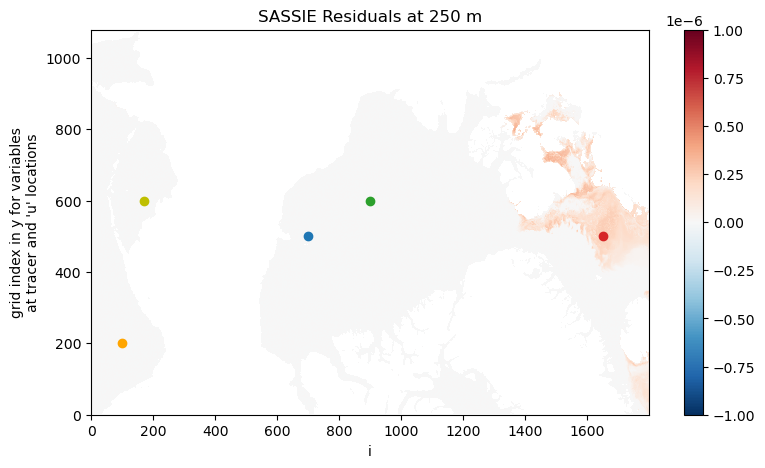

In [169]:
res_sassie.isel(k=30).plot(cmap='RdBu_r',vmin=-1e-6,vmax=1e-6,figsize=[9,5]);

# add points for locations where vertical profiles were plotted below
plt.scatter(900,600,c='tab:green');
plt.scatter(700,500,c='tab:blue');
plt.scatter(170,600,c='y');
plt.scatter(100,200,c='orange');
plt.scatter(1650,500,c='tab:red');
plt.title("SASSIE Residuals at 250 m");

### Plot SASSIE residuals at several depths (same colorbar scale)

In [170]:
print(res_sassie.isel(k=30).Z.values)
print(res_sassie.isel(k=39).Z.values)
print(res_sassie.isel(k=43).Z.values)
print(res_sassie.isel(k=51).Z.values)

-251.77
-506.54
-650.855
-992.26


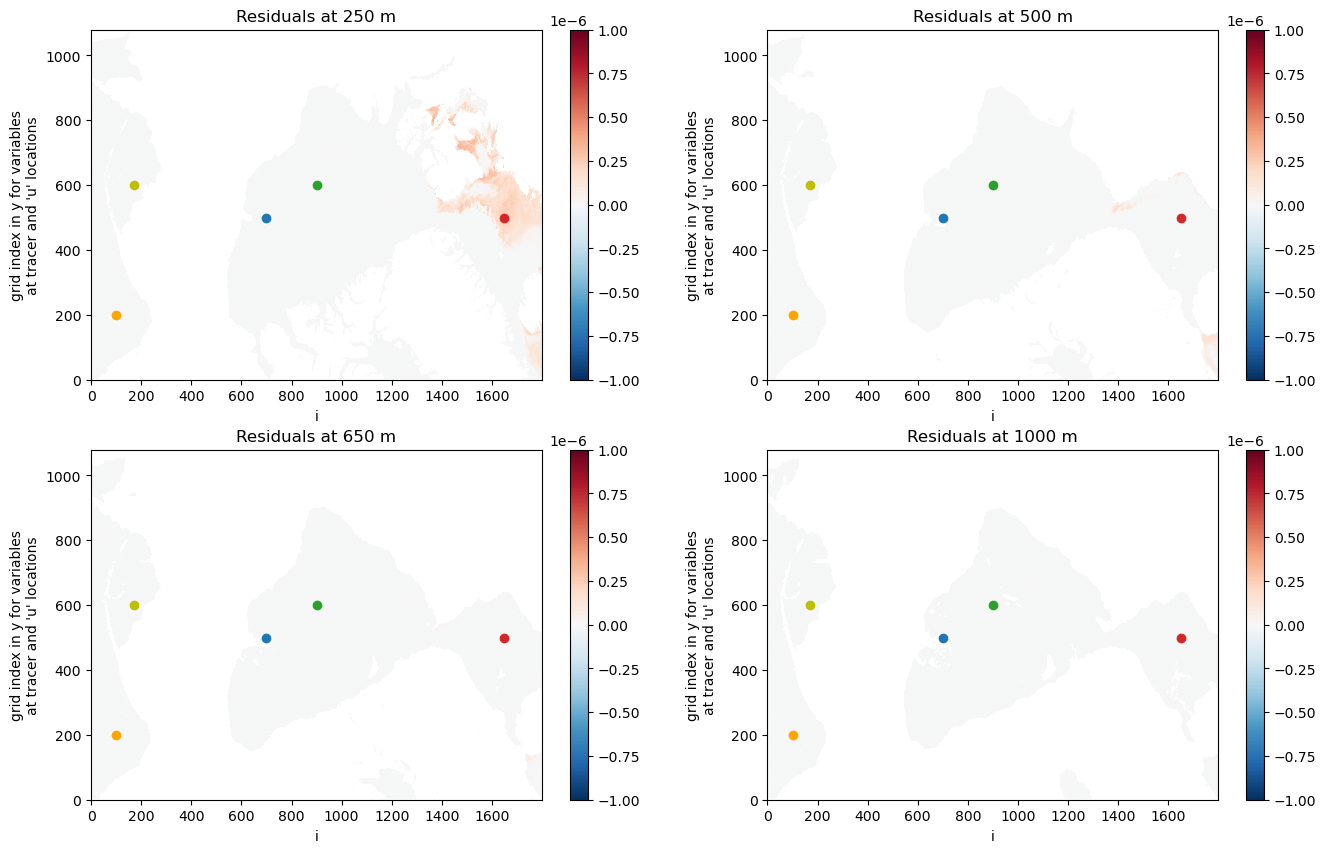

In [171]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=[16,10])

res_sassie.isel(k=30).plot(ax=ax1,cmap='RdBu_r',vmin=-1e-6,vmax=1e-6) # 250 m
res_sassie.isel(k=39).plot(ax=ax2,cmap='RdBu_r',vmin=-1e-6,vmax=1e-6) # 500 m
res_sassie.isel(k=43).plot(ax=ax3,cmap='RdBu_r',vmin=-1e-6,vmax=1e-6) # 650 m
res_sassie.isel(k=51).plot(ax=ax4,cmap='RdBu_r',vmin=-1e-6,vmax=1e-6) # 1000 m

# add points for locations where vertical profiles were plotted below
for ax in (ax1,ax2,ax3,ax4):
    ax.scatter(900,600,c='tab:green')
    ax.scatter(700,500,c='tab:blue')
    ax.scatter(170,600,c='y')
    ax.scatter(100,200,c='orange')
    ax.scatter(1650,500,c='tab:red')

ax1.set_title("Residuals at 250 m")
ax2.set_title("Residuals at 500 m")
ax3.set_title("Residuals at 650 m")
ax4.set_title("Residuals at 1000 m");

### Plot SASSIE residuals at several depths (smaller colorbar scale)

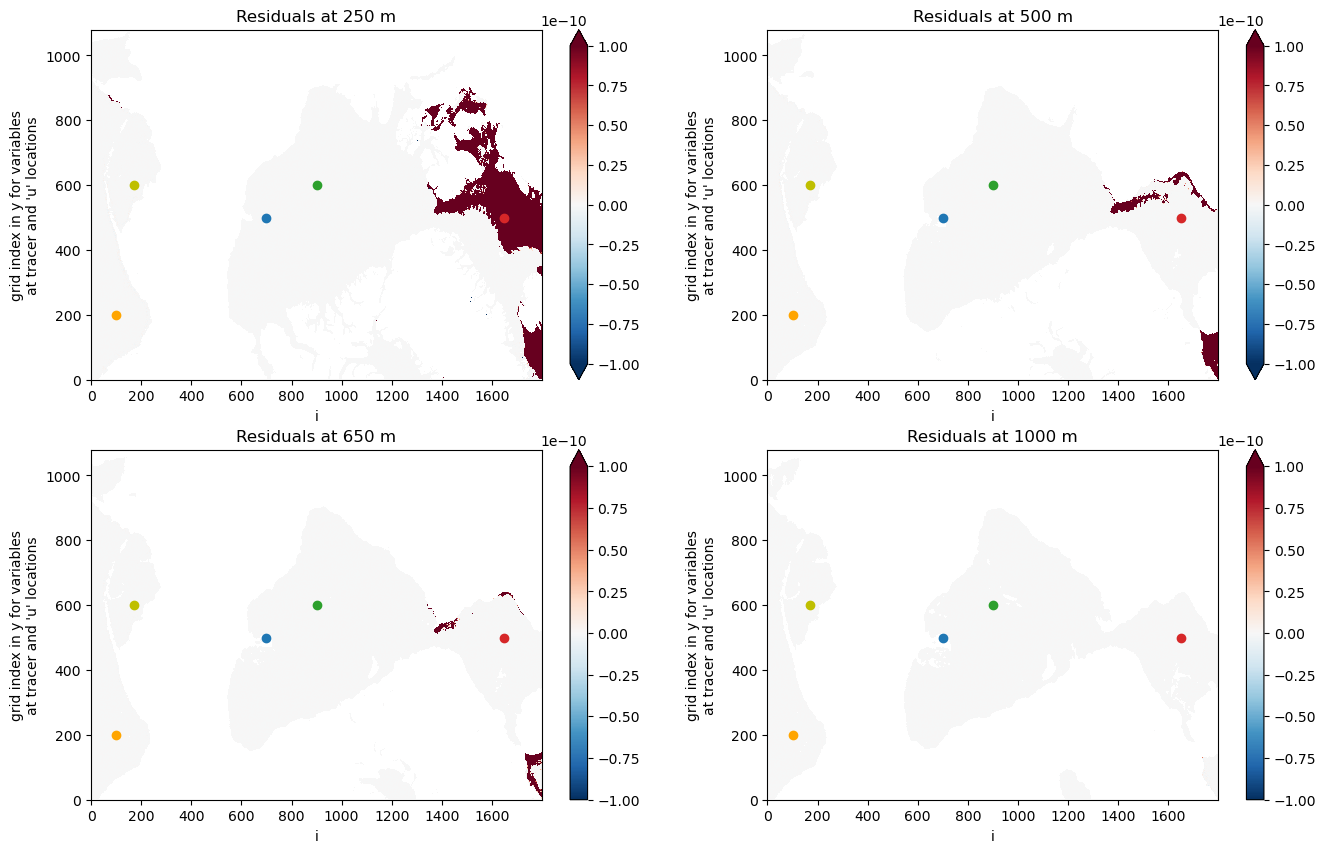

In [172]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=[16,10])

res_sassie.isel(k=30).plot(ax=ax1,cmap='RdBu_r',vmin=-1e-10,vmax=1e-10) # 250 m
res_sassie.isel(k=39).plot(ax=ax2,cmap='RdBu_r',vmin=-1e-10,vmax=1e-10) # 500 m
res_sassie.isel(k=43).plot(ax=ax3,cmap='RdBu_r',vmin=-1e-10,vmax=1e-10) # 650 m
res_sassie.isel(k=51).plot(ax=ax4,cmap='RdBu_r',vmin=-1e-10,vmax=1e-10) # 1000 m

# add points for locations where vertical profiles were plotted below
for ax in (ax1,ax2,ax3,ax4):
    ax.scatter(900,600,c='tab:green')
    ax.scatter(700,500,c='tab:blue')
    ax.scatter(170,600,c='y')
    ax.scatter(100,200,c='orange')
    ax.scatter(1650,500,c='tab:red')

ax1.set_title("Residuals at 250 m")
ax2.set_title("Residuals at 500 m")
ax3.set_title("Residuals at 650 m")
ax4.set_title("Residuals at 1000 m");

### Plot vertical profiles of residuals

In [173]:
res_sassie_depth = res_sassie.swap_dims({'k':'Z'})

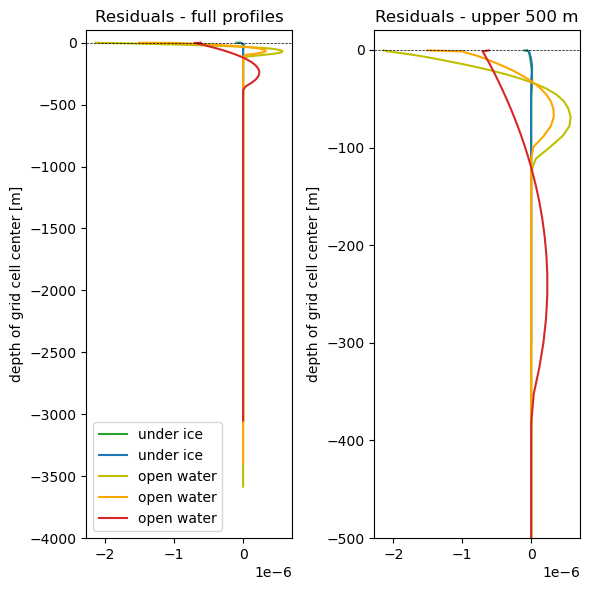

In [174]:
# plot some profiles
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[6,6])

res_sassie_depth.isel(i=900,j=600).plot(ax=ax1,y='Z',c='tab:green',label='under ice');
res_sassie_depth.isel(i=700,j=500).plot(ax=ax1,y='Z',c='tab:blue',label='under ice');
res_sassie_depth.isel(i=170,j=600).plot(ax=ax1,y='Z',c='y',label='open water');
res_sassie_depth.isel(i=100,j=200).plot(ax=ax1,y='Z',c='orange',label='open water');
res_sassie_depth.isel(i=1650,j=500).plot(ax=ax1,y='Z',c='tab:red',label='open water');
ax1.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax1.set_ylim(-4000,100);
ax1.set_title("Residuals - full profiles");
ax1.legend()

res_sassie_depth.isel(i=900,j=600).plot(ax=ax2,y='Z',c='tab:green');
res_sassie_depth.isel(i=700,j=500).plot(ax=ax2,y='Z',c='tab:blue');
res_sassie_depth.isel(i=170,j=600).plot(ax=ax2,y='Z',c='y');
res_sassie_depth.isel(i=100,j=200).plot(ax=ax2,y='Z',c='orange');
res_sassie_depth.isel(i=1650,j=500).plot(ax=ax2,y='Z',c='tab:red');
ax2.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax2.set_ylim(-500,20);
ax2.set_title("Residuals - upper 500 m");

plt.tight_layout()

### Plot SASSIE residuals at several depths (smaller colorbar scale)

In [175]:
print(res_sassie.isel(k=0).Z.values)
print(res_sassie.isel(k=30).Z.values)
print(res_sassie.isel(k=43).Z.values)
print(res_sassie.isel(k=48).Z.values)

-0.5
-251.77
-650.855
-855.835


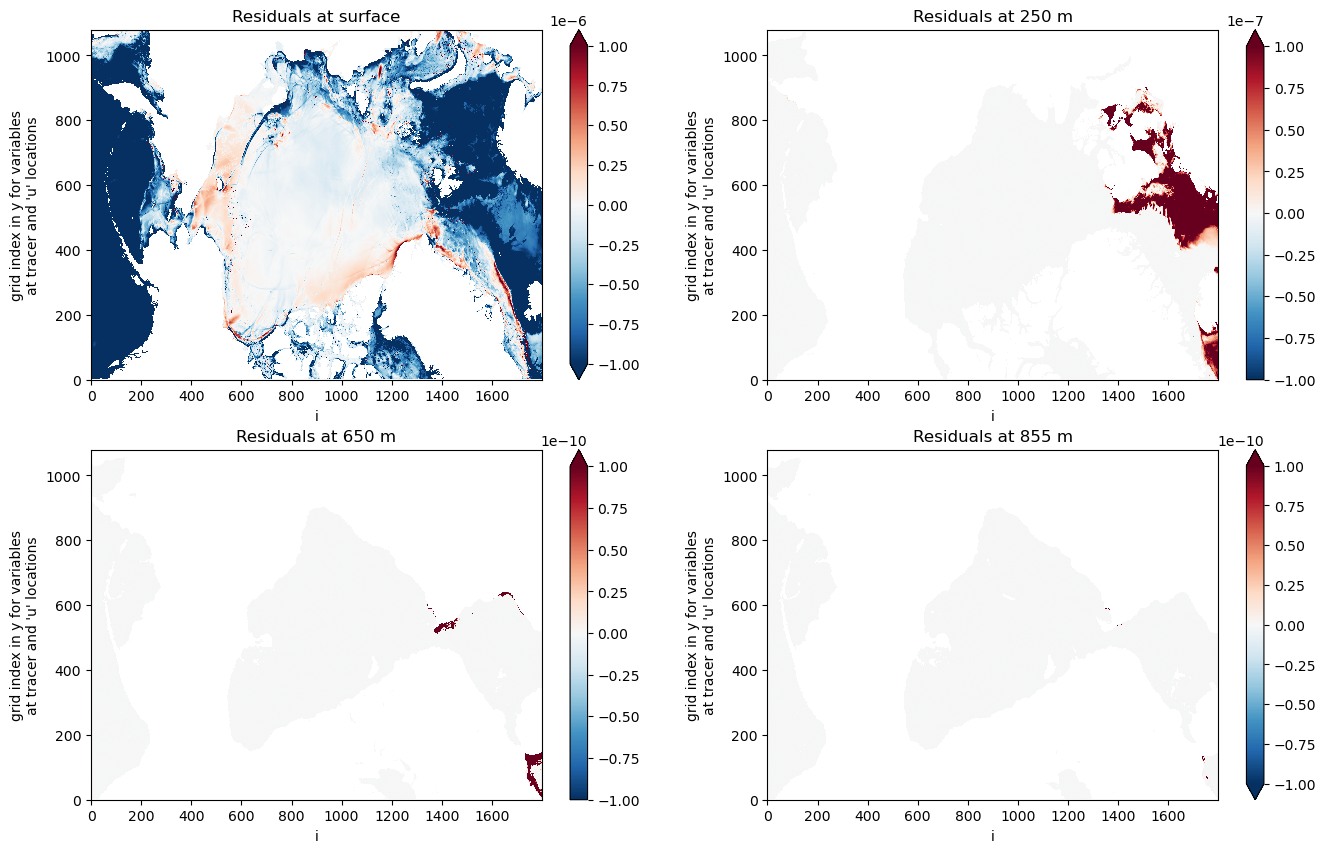

In [176]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=[16,10])

res_sassie.isel(k=0).plot(ax=ax1,cmap='RdBu_r',vmin=-1e-6,vmax=1e-6) # 250 m
res_sassie.isel(k=30).plot(ax=ax2,cmap='RdBu_r',vmin=-1e-7,vmax=1e-7) # 500 m
res_sassie.isel(k=43).plot(ax=ax3,cmap='RdBu_r',vmin=-1e-10,vmax=1e-10) # 650 m
res_sassie.isel(k=48).plot(ax=ax4,cmap='RdBu_r',vmin=-1e-10,vmax=1e-10) # 855 m

ax1.set_title("Residuals at surface")
ax2.set_title("Residuals at 250 m")
ax3.set_title("Residuals at 650 m")
ax4.set_title("Residuals at 855 m");

### compare ECCO and SASSIE residuals at the surface

In [177]:
res_sassie_rot = res_sassie.isel(k=0,i=slice(500,1600))
sassie_rot90 = np.rot90(res_sassie_rot,2)
res_sassie_rot.values = sassie_rot90

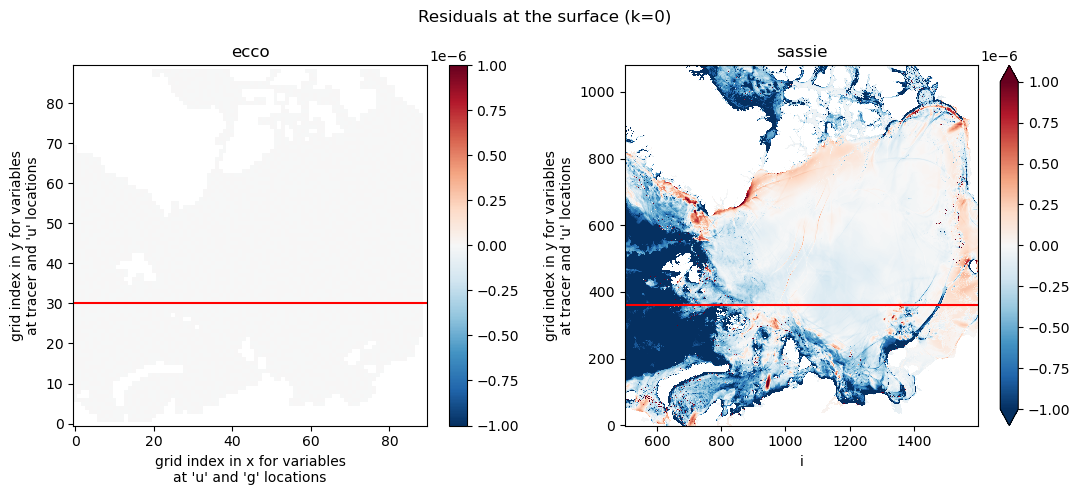

In [178]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[11,5])
res_ecco.isel(k=0).plot(ax=ax1,cmap='RdBu_r',vmin=-1e-6,vmax=1e-6);
res_sassie_rot.plot(ax=ax2,cmap='RdBu_r',vmin=-1e-6,vmax=1e-6);
ax1.set_title("ecco")
ax2.set_title("sassie");
plt.suptitle("Residuals at the surface (k=0)")
ax1.axhline(y=30,color='r')
ax2.axhline(y=360,color='r')
plt.tight_layout()

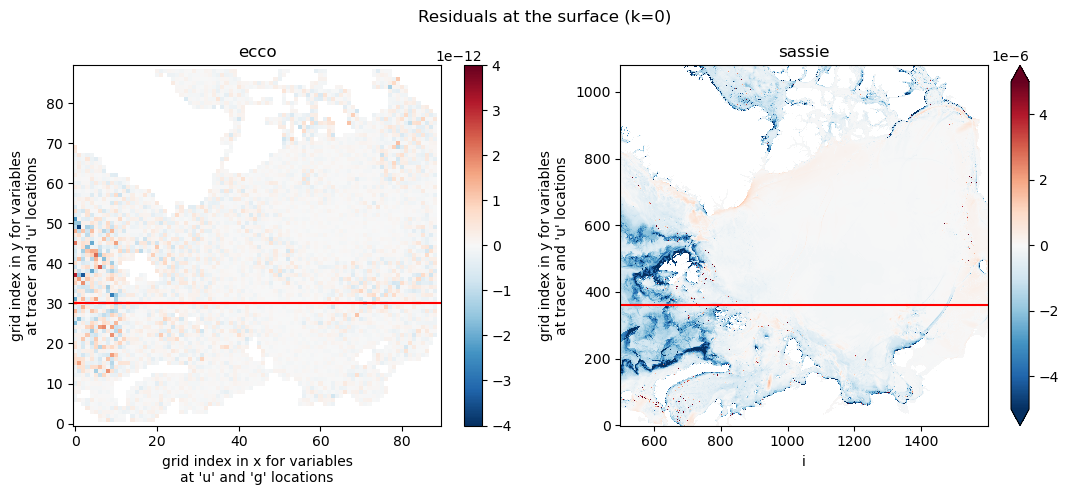

In [179]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[11,5])
res_ecco.isel(k=0).plot(ax=ax1,cmap='RdBu_r',vmin=-4e-12,vmax=4e-12);
res_sassie_rot.plot(ax=ax2,cmap='RdBu_r',vmin=-5e-6,vmax=5e-6);
ax1.set_title("ecco")
ax2.set_title("sassie");
plt.suptitle("Residuals at the surface (k=0)")
ax1.axhline(y=30,color='r')
ax2.axhline(y=360,color='r')
plt.tight_layout()

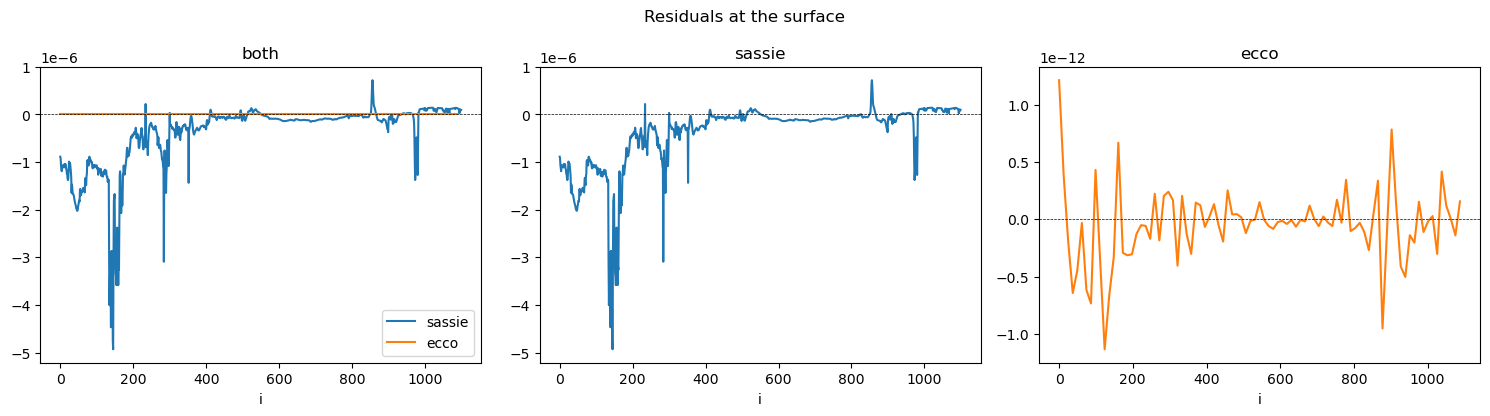

In [180]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[15,4])

ax1.set_title('both')
ax1.plot(res_sassie_rot.isel(j=360),label='sassie')
ax1.plot(np.linspace(0,1100,90),res_ecco.isel(k=0,j=30),label='ecco')

plt.suptitle('Residuals at the surface')
ax1.legend()

ax2.set_title('sassie')
ax2.plot(res_sassie_rot.isel(j=360),label='sassie')

ax3.set_title('ecco')
ax3.plot(np.linspace(0,1100,90),res_ecco.isel(k=0,j=30),label='ecco',c='tab:orange');
plt.tight_layout()

for ax in (ax1,ax2,ax3):
    ax.set_xlabel("i")
    ax.axhline(y=0,color='k',linewidth=0.5,linestyle='dashed');

In [181]:
res_sassie_rot = res_sassie.isel(k=16,i=slice(500,1600))
sassie_rot90 = np.rot90(res_sassie_rot,2)
res_sassie_rot.values = sassie_rot90

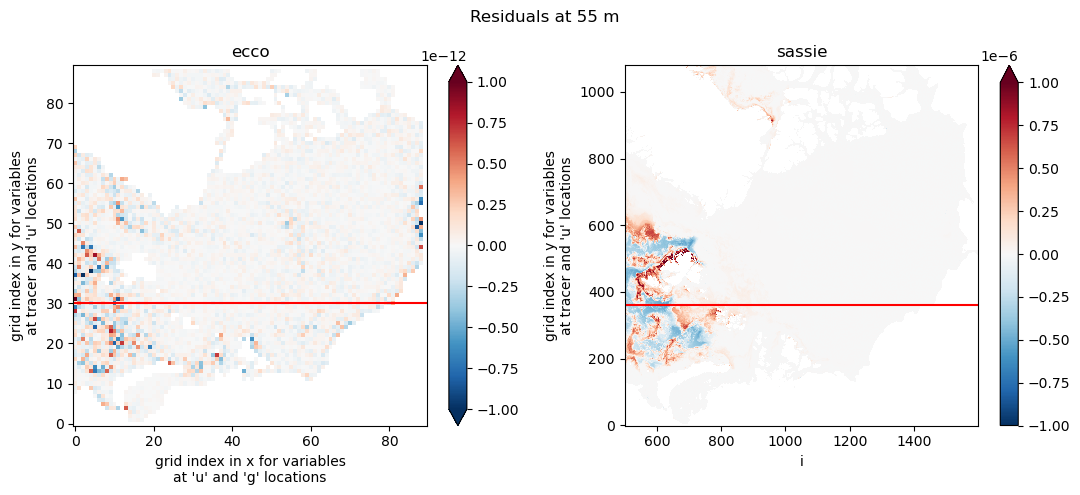

In [182]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[11,5])
res_ecco.isel(k=5).plot(ax=ax1,cmap='RdBu_r',vmin=-1e-12,vmax=1e-12);
res_sassie_rot.plot(ax=ax2,cmap='RdBu_r',vmin=-1e-6,vmax=1e-6);
ax1.set_title("ecco")
ax2.set_title("sassie");
plt.suptitle("Residuals at 55 m")
ax1.axhline(y=30,color='r')
ax2.axhline(y=360,color='r')
plt.tight_layout()

# Plot everything together

In [183]:
# load sassie data
G_total_sassie_row = G_total_sassie.isel(k=0,i=slice(500,1600))
sassie_rot90 = np.rot90(G_total_sassie_row,2)
G_total_sassie_row.values = sassie_rot90

G_advection_sassie_row = G_advection_sassie.isel(k=0,i=slice(500,1600))
sassie_rot90 = np.rot90(G_advection_sassie_row,2)
G_advection_sassie_row.values = sassie_rot90

G_diffusion_sassie_row = G_diffusion_sassie.isel(k=0,i=slice(500,1600))
sassie_rot90 = np.rot90(G_diffusion_sassie_row,2)
G_diffusion_sassie_row.values = sassie_rot90

G_forcing_sassie_row = G_forcing_sassie.isel(k=0,i=slice(500,1600))
sassie_rot90 = np.rot90(G_forcing_sassie_row,2)
G_forcing_sassie_row.values = sassie_rot90

In [184]:
rhs_sassie_row = (G_advection_sassie_row.isel(j=360) + G_diffusion_sassie_row.isel(j=360) + G_forcing_sassie_row.isel(j=360)).compute()
res_sassie_row = (rhs_sassie_row - G_total_sassie_row.isel(j=360)).compute()

In [185]:
rhs_ecco_row = (G_advection_ecco.isel(k=0,j=30) + G_diffusion_ecco.isel(k=0,j=30) + G_forcing_ecco.isel(k=0,j=30)).compute()
res_ecco_row = (rhs_ecco_row - G_total_ecco.isel(k=0,j=30)).compute()

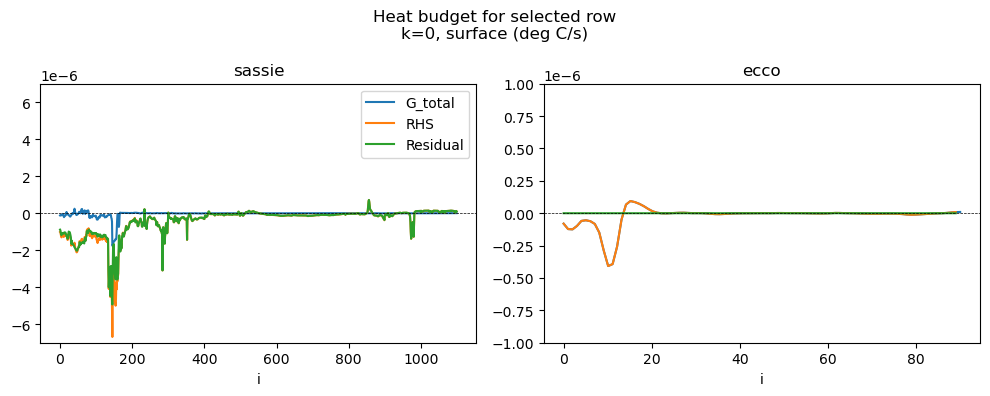

In [186]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[10,4])
plt.suptitle('Heat budget for selected row\nk=0, surface (deg C/s)')

ax1.set_title('sassie')
ax1.plot(G_total_sassie_row.isel(j=360),label='G_total')
ax1.plot(rhs_sassie_row,label='RHS')
ax1.plot(res_sassie_row,label='Residual')

ax2.set_title('ecco')
ax2.plot(np.linspace(0,90,90),G_total_ecco.isel(k=0,j=30))
ax2.plot(np.linspace(0,90,90),rhs_ecco_row)
ax2.plot(np.linspace(0,90,90),res_ecco_row)

plt.tight_layout()

for ax in (ax1,ax2):
    ax.set_xlabel("i")
    ax.axhline(y=0,color='k',linewidth=0.5,linestyle='dashed');

ax1.set_ylim(-7e-6,7e-6)
ax2.set_ylim(-1e-6,1e-6)
# ax1.set_xlim(0,400)
# ax2.set_xlim(0,33)
plt.tight_layout()
ax1.legend();

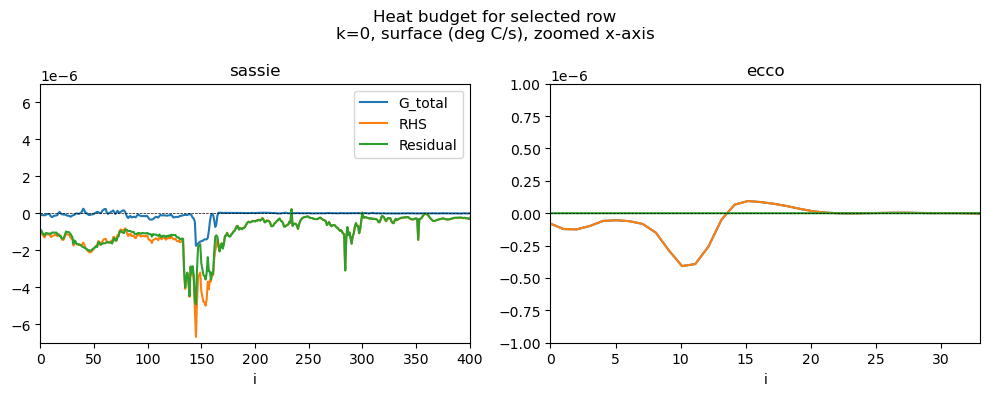

In [187]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[10,4])
plt.suptitle('Heat budget for selected row\nk=0, surface (deg C/s), zoomed x-axis')

ax1.set_title('sassie')
ax1.plot(G_total_sassie_row.isel(j=360),label='G_total')
ax1.plot(rhs_sassie_row,label='RHS')
ax1.plot(res_sassie_row,label='Residual')

ax2.set_title('ecco')
ax2.plot(np.linspace(0,90,90),G_total_ecco.isel(k=0,j=30))
ax2.plot(np.linspace(0,90,90),rhs_ecco_row)
ax2.plot(np.linspace(0,90,90),res_ecco_row)

plt.tight_layout()

for ax in (ax1,ax2):
    ax.set_xlabel("i")
    ax.axhline(y=0,color='k',linewidth=0.5,linestyle='dashed');

ax1.set_ylim(-7e-6,7e-6)
ax2.set_ylim(-1e-6,1e-6)
ax1.set_xlim(0,400)
ax2.set_xlim(0,33)
plt.tight_layout()
ax1.legend();

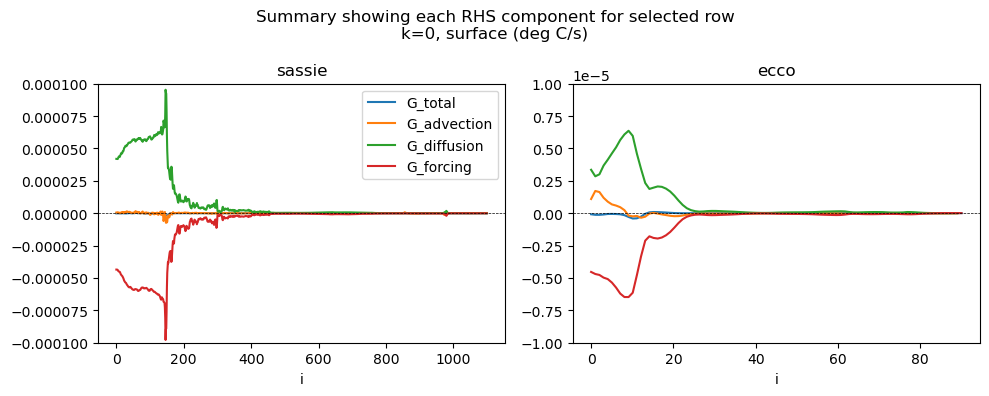

In [188]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[10,4])
plt.suptitle('Summary showing each RHS component for selected row\nk=0, surface (deg C/s)')

ax1.set_title('sassie')
ax1.plot(G_total_sassie_row.isel(j=360),label='G_total')
ax1.plot(G_advection_sassie_row.isel(j=360),label='G_advection')
ax1.plot(G_diffusion_sassie_row.isel(j=360),label='G_diffusion')
ax1.plot(G_forcing_sassie_row.isel(j=360),label='G_forcing')

ax2.set_title('ecco')
ax2.plot(np.linspace(0,90,90),G_total_ecco.isel(k=0,j=30))
ax2.plot(np.linspace(0,90,90),G_advection_ecco.isel(k=0,j=30))
ax2.plot(np.linspace(0,90,90),G_diffusion_ecco.isel(k=0,j=30))
ax2.plot(np.linspace(0,90,90),G_forcing_ecco.isel(k=0,j=30))

plt.tight_layout()

for ax in (ax1,ax2):
    ax.set_xlabel("i")
    ax.axhline(y=0,color='k',linewidth=0.5,linestyle='dashed');

ax1.set_ylim(-1e-4,1e-4)
ax2.set_ylim(-1e-5,1e-5)
plt.tight_layout()
ax1.legend();

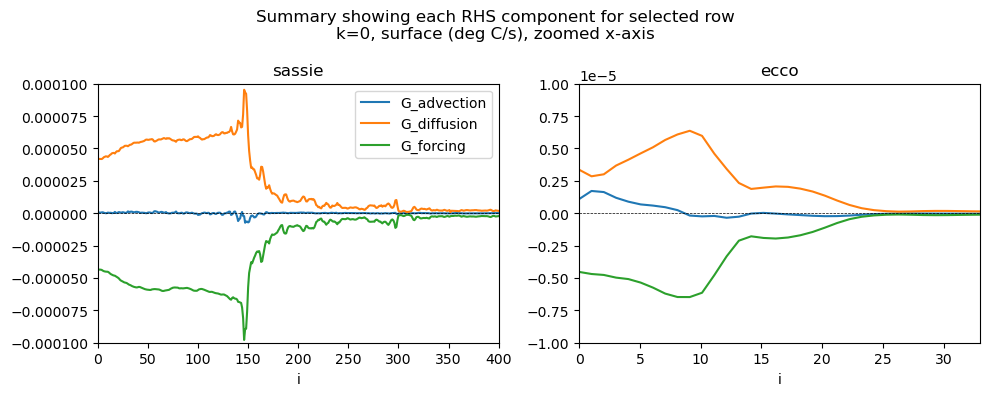

In [189]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[10,4])
plt.suptitle('Summary showing each RHS component for selected row\nk=0, surface (deg C/s), zoomed x-axis')

ax1.set_title('sassie')
# ax1.plot(G_total_sassie_row.isel(j=360),label='G_total')
ax1.plot(G_advection_sassie_row.isel(j=360),label='G_advection')
ax1.plot(G_diffusion_sassie_row.isel(j=360),label='G_diffusion')
ax1.plot(G_forcing_sassie_row.isel(j=360),label='G_forcing')

ax2.set_title('ecco')
# ax2.plot(np.linspace(0,90,90),G_total_ecco.isel(k=0,j=30))
ax2.plot(np.linspace(0,90,90),G_advection_ecco.isel(k=0,j=30))
ax2.plot(np.linspace(0,90,90),G_diffusion_ecco.isel(k=0,j=30))
ax2.plot(np.linspace(0,90,90),G_forcing_ecco.isel(k=0,j=30))

plt.tight_layout()

for ax in (ax1,ax2):
    ax.set_xlabel("i")
    ax.axhline(y=0,color='k',linewidth=0.5,linestyle='dashed');

ax1.set_ylim(-1e-4,1e-4)
ax2.set_ylim(-1e-5,1e-5)
ax1.set_xlim(0,400)
ax2.set_xlim(0,33)
plt.tight_layout()
ax1.legend();

### Histogram of residuals

#### ECCO

In [190]:
tmp = np.abs(res_ecco).values.ravel()

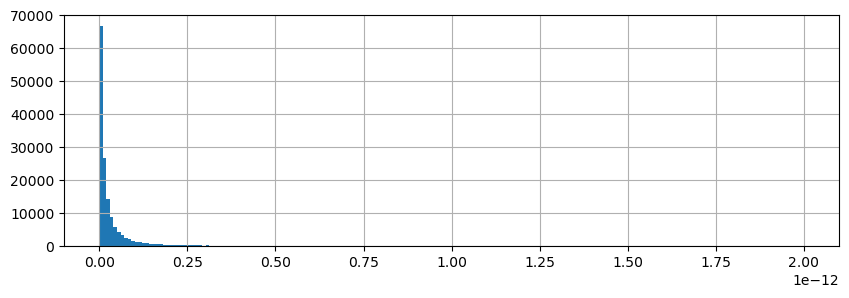

In [191]:
plt.figure(figsize=(10,3));

plt.hist(tmp[tmp > 0],np.linspace(0, 2.e-12, 200));
plt.grid()

#### SASSIE - only surface

In [192]:
res_sassie_ravel = np.abs(res_sassie.isel(k=0).values.ravel())

In [193]:
res_sassie_ravel.shape

(1944000,)

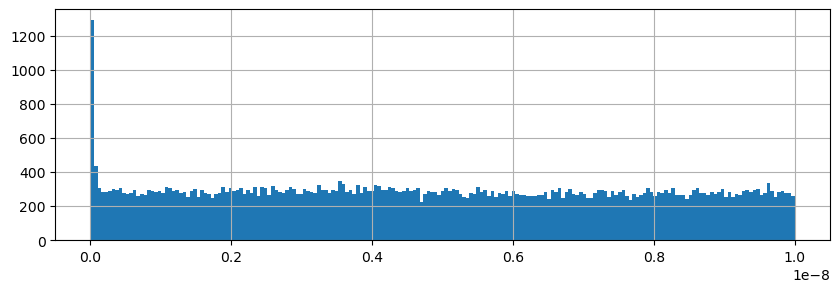

In [194]:
plt.figure(figsize=(10,3));
# plt.hist(tmp[tmp > 0])
# plt.hist(tmp[tmp > 0],np.linspace(0, 2.e-12, 200));
plt.hist(res_sassie_ravel[res_sassie_ravel > 0],np.linspace(0, 1e-8, 200));
plt.grid()

#### SASSIE - below 2000 m

In [195]:
res_sassie.isel(k=67).Z.values

array(-1995.905, dtype=float32)

In [196]:
# select residuals below 2000 m
res_sassie_below2000 = res_sassie.isel(k=slice(67,90))

In [197]:
res_sassie_below2000_ravel = np.abs(res_sassie_below2000.values.ravel())

In [198]:
res_sassie_below2000_ravel.shape

(44712000,)

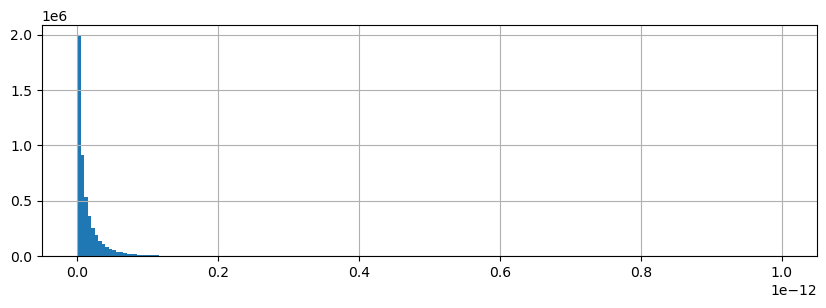

In [199]:
plt.figure(figsize=(10,3));
# plt.hist(tmp[tmp > 0])
# plt.hist(tmp[tmp > 0],np.linspace(0, 2.e-12, 200));
plt.hist(res_sassie_below2000_ravel[res_sassie_below2000_ravel > 0],np.linspace(0, 1e-12, 200));
plt.grid()

#### SASSIE - masking out cells where KPPdiffS is elevated

In [200]:
# open KPPdiffS dataset
KPPdiffS_zarr = open_zarr_store('s3://podaac-dev-sassie/ECCO_model/N1/V1R1/HH/ZARR/KPPdiffS_AVG_DAILY.ZARR/', s3_options)

In [201]:
# take mean over March 2014 snapshot period
KPPdiffS_march = KPPdiffS_zarr.KPPdiffS.sel(time=slice(etan_monthly_snaps.time.values[0], etan_monthly_snaps.time.values[1])).mean('time').compute()

In [202]:
res_sassie_kpp_mask = res_sassie.where(KPPdiffS_march.values<1e-5)

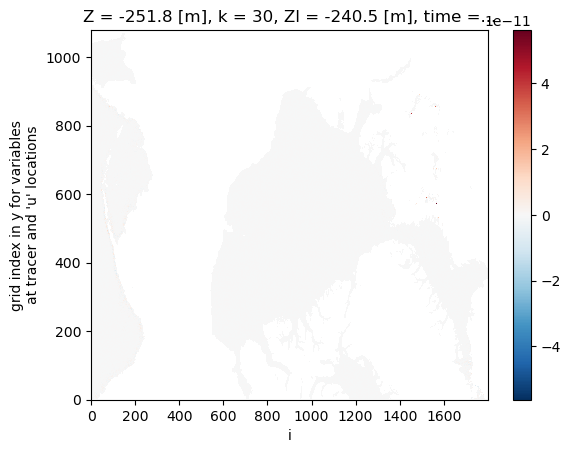

In [203]:
res_sassie_kpp_mask.isel(k=30).plot()

In [204]:
res_sassie_kpp_mask_ravel = np.abs(res_sassie_kpp_mask.values.ravel())

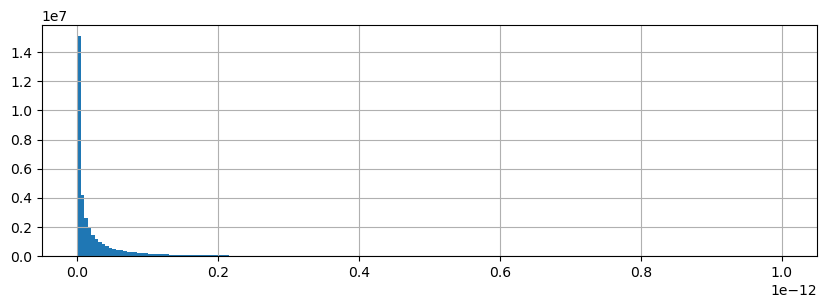

In [205]:
plt.figure(figsize=(10,3));
plt.hist(res_sassie_kpp_mask_ravel[res_sassie_kpp_mask_ravel > 0],np.linspace(0, 1e-12, 200));
plt.grid()

## Look at deeper grid cells at ~250 m

In [206]:
HH_grid.isel(k=30).Z.values

array(-251.77, dtype=float32)

In [207]:
res_sassie_rot = res_sassie.isel(k=30,i=slice(500,1600))
sassie_rot90 = np.rot90(res_sassie_rot,2)
res_sassie_rot.values = sassie_rot90

In [208]:
# load sassie data
G_total_sassie_row = G_total_sassie.isel(k=30,i=slice(500,1600))
sassie_rot90 = np.rot90(G_total_sassie_row,2)
G_total_sassie_row.values = sassie_rot90

G_advection_sassie_row = G_advection_sassie.isel(k=30,i=slice(500,1600))
sassie_rot90 = np.rot90(G_advection_sassie_row,2)
G_advection_sassie_row.values = sassie_rot90

G_diffusion_sassie_row = G_diffusion_sassie.isel(k=30,i=slice(500,1600))
sassie_rot90 = np.rot90(G_diffusion_sassie_row,2)
G_diffusion_sassie_row.values = sassie_rot90

G_forcing_sassie_row = G_forcing_sassie.isel(k=30,i=slice(500,1600))
sassie_rot90 = np.rot90(G_forcing_sassie_row,2)
G_forcing_sassie_row.values = sassie_rot90

In [209]:
rhs_sassie_row = (G_advection_sassie_row.isel(j=360) + G_diffusion_sassie_row.isel(j=360) + G_forcing_sassie_row.isel(j=360)).compute()
res_sassie_row = (rhs_sassie_row - G_total_sassie_row.isel(j=360)).compute()

In [210]:
rhs_ecco_row = (G_advection_ecco.isel(k=18,j=30) + G_diffusion_ecco.isel(k=18,j=30) + G_forcing_ecco.isel(k=18,j=30)).compute()
res_ecco_row = (rhs_ecco_row - G_total_ecco.isel(k=18,j=30)).compute()

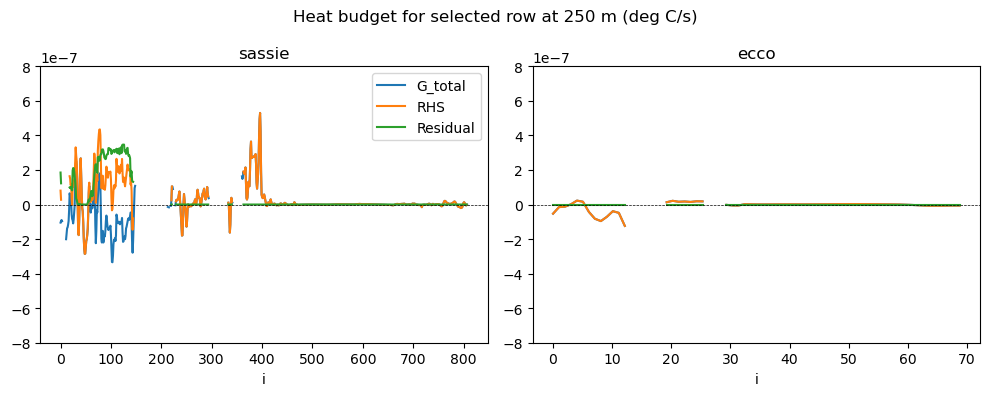

In [211]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[10,4])
plt.suptitle('Heat budget for selected row at 250 m (deg C/s)')

ax1.set_title('sassie')
ax1.plot(G_total_sassie_row.isel(j=360),label='G_total')
ax1.plot(rhs_sassie_row,label='RHS')
ax1.plot(res_sassie_row,label='Residual')

ax2.set_title('ecco')
ax2.plot(np.linspace(0,90,90),G_total_ecco.isel(k=18,j=30))
ax2.plot(np.linspace(0,90,90),rhs_ecco_row)
ax2.plot(np.linspace(0,90,90),res_ecco_row)

plt.tight_layout()

for ax in (ax1,ax2):
    ax.set_xlabel("i")
    ax.axhline(y=0,color='k',linewidth=0.5,linestyle='dashed');

ax1.set_ylim(-8e-7,8e-7)
ax2.set_ylim(-8e-7,8e-7)
# ax1.set_xlim(0,400)
# ax2.set_xlim(0,33)
plt.tight_layout()
ax1.legend();

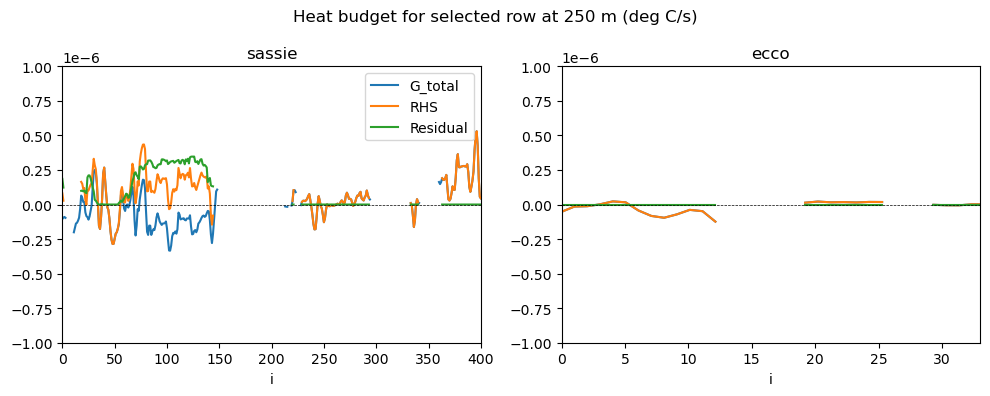

In [212]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[10,4])
plt.suptitle('Heat budget for selected row at 250 m (deg C/s)')

ax1.set_title('sassie')
ax1.plot(G_total_sassie_row.isel(j=360),label='G_total')
ax1.plot(rhs_sassie_row,label='RHS')
ax1.plot(res_sassie_row,label='Residual')

ax2.set_title('ecco')
ax2.plot(np.linspace(0,90,90),G_total_ecco.isel(k=18,j=30))
ax2.plot(np.linspace(0,90,90),rhs_ecco_row)
ax2.plot(np.linspace(0,90,90),res_ecco_row)

plt.tight_layout()

for ax in (ax1,ax2):
    ax.set_xlabel("i")
    ax.axhline(y=0,color='k',linewidth=0.5,linestyle='dashed');

ax1.set_ylim(-1e-6,1e-6)
ax2.set_ylim(-1e-6,1e-6)
ax1.set_xlim(0,400)
ax2.set_xlim(0,33)
plt.tight_layout()
ax1.legend();

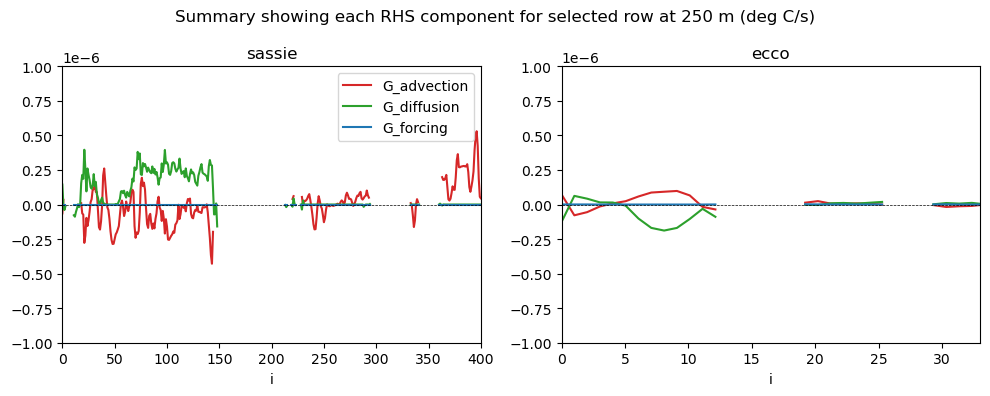

In [213]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[10,4])
plt.suptitle('Summary showing each RHS component for selected row at 250 m (deg C/s)')

ax1.set_title('sassie')
# ax1.plot(G_total_sassie_row.isel(j=360),label='G_total')
ax1.plot(G_advection_sassie_row.isel(j=360),label='G_advection',color='tab:red')
ax1.plot(G_diffusion_sassie_row.isel(j=360),label='G_diffusion',color='tab:green')
ax1.plot(G_forcing_sassie_row.isel(j=360),label='G_forcing',color='tab:blue')

ax2.set_title('ecco')
# ax2.plot(np.linspace(0,90,90),G_total_ecco.isel(k=18,j=30))
ax2.plot(np.linspace(0,90,90),G_advection_ecco.isel(k=18,j=30),color='tab:red')
ax2.plot(np.linspace(0,90,90),G_diffusion_ecco.isel(k=18,j=30),color='tab:green')
ax2.plot(np.linspace(0,90,90),G_forcing_ecco.isel(k=18,j=30),color='tab:blue')

plt.tight_layout()

for ax in (ax1,ax2):
    ax.set_xlabel("i")
    ax.axhline(y=0,color='k',linewidth=0.5,linestyle='dashed');

ax1.set_ylim(-1e-6,1e-6)
ax2.set_ylim(-1e-6,1e-6)
ax1.set_xlim(0,400)
ax2.set_xlim(0,33)
plt.tight_layout()
ax1.legend();

## Comparison of vertical profiles of residuals and `KPPdiffS`

### Take a look at sea ice cover for this period

In [214]:
# open sea ice dataset
SIarea_zarr = open_zarr_store('s3://podaac-dev-sassie/ECCO_model/N1/V1R1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options)

In [215]:
# take mean over March 2014 snapshot period
SI_march = SIarea_zarr.SIarea.sel(time=slice(etan_monthly_snaps.time.values[0], etan_monthly_snaps.time.values[1])).mean('time').compute()

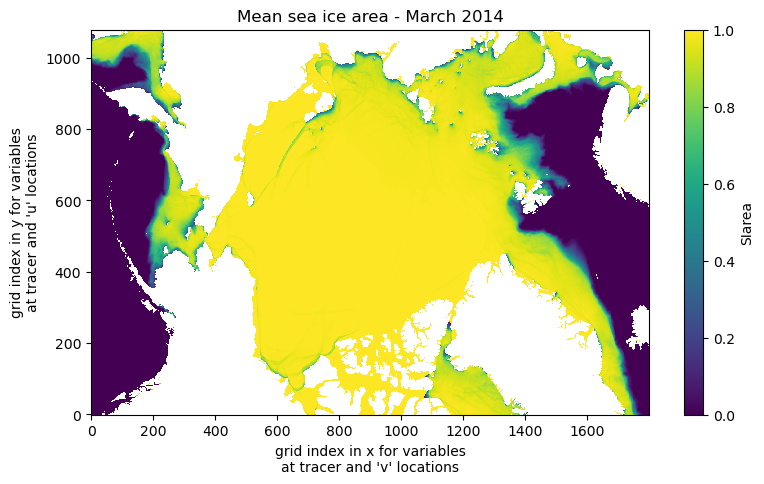

In [216]:
# plot
SI_march.plot(figsize=[9,5]);
plt.title("Mean sea ice area - March 2014");

### Load KPPdiffS (equivalent to KPPdiffT, which is why Mike turned off KPPdiffT early)

### Select points

In [217]:
print(res_sassie.isel(k=39).Z.values)

-506.54


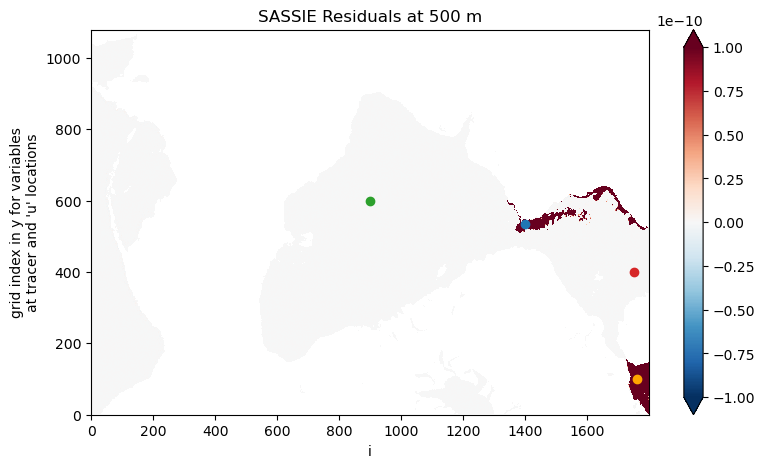

In [218]:
res_sassie.isel(k=39).plot(cmap='RdBu_r',vmin=-1e-10,vmax=1e-10,figsize=[9,5]);

# add points for locations of vertical profiles that are plotted below
plt.scatter(900,600,c='tab:green');
plt.scatter(1400,535,c='tab:blue');
plt.scatter(1750,400,c='tab:red');
plt.scatter(1760,100,c='orange');
plt.title("SASSIE Residuals at 500 m");

In [219]:
res_sassie_depth = res_sassie.swap_dims({'k':'Z'})

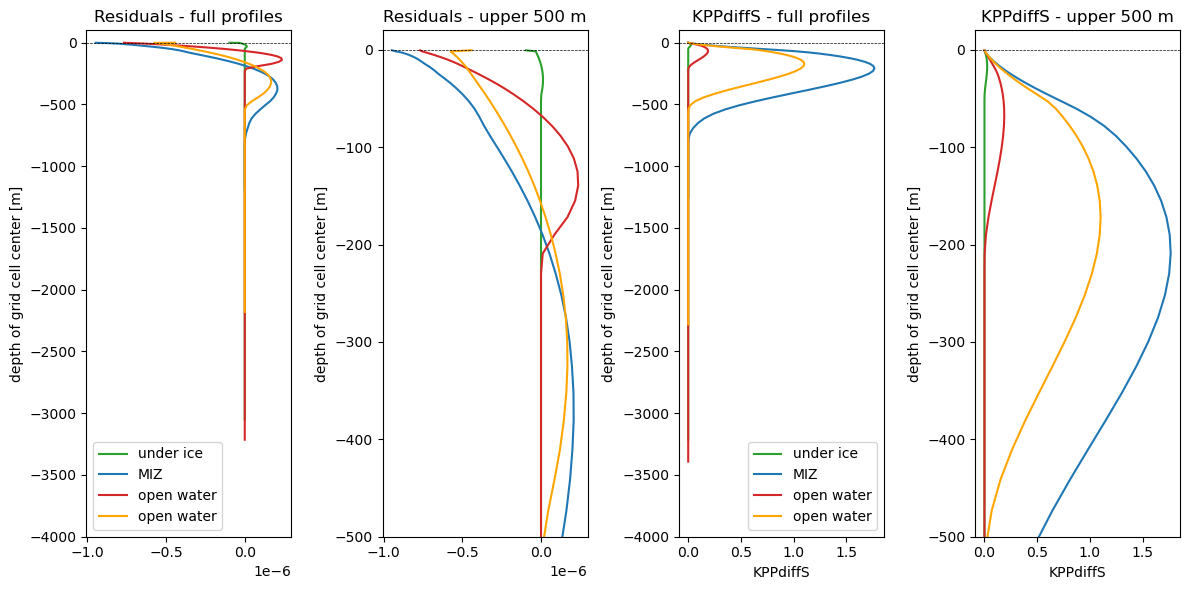

In [220]:
# plot some profiles
fig, (ax1,ax2,ax3,ax4) = plt.subplots(1,4,figsize=[12,6])

res_sassie_depth.isel(i=900,j=600).plot(ax=ax1,y='Z',c='tab:green',label='under ice');
res_sassie_depth.isel(i=1400,j=535).plot(ax=ax1,y='Z',c='tab:blue',label='MIZ');
res_sassie_depth.isel(i=1750,j=400).plot(ax=ax1,y='Z',c='tab:red',label='open water');
res_sassie_depth.isel(i=1760,j=100).plot(ax=ax1,y='Z',c='orange',label='open water');
ax1.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax1.set_ylim(-4000,100);
ax1.set_title("Residuals - full profiles");
ax1.legend()

res_sassie_depth.isel(i=900,j=600).plot(ax=ax2,y='Z',c='tab:green');
res_sassie_depth.isel(i=1400,j=535).plot(ax=ax2,y='Z',c='tab:blue');
res_sassie_depth.isel(i=1750,j=400).plot(ax=ax2,y='Z',c='tab:red');
res_sassie_depth.isel(i=1760,j=100).plot(ax=ax2,y='Z',c='orange');
ax2.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax2.set_ylim(-500,20);
ax2.set_title("Residuals - upper 500 m");

KPPdiffS_march.isel(i=900,j=600).plot(ax=ax3,y='Z',c='tab:green',label='under ice');
KPPdiffS_march.isel(i=1400,j=535).plot(ax=ax3,y='Z',c='tab:blue',label='MIZ');
KPPdiffS_march.isel(i=1750,j=400).plot(ax=ax3,y='Z',c='tab:red',label='open water');
KPPdiffS_march.isel(i=1760,j=100).plot(ax=ax3,y='Z',c='orange',label='open water');
ax3.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax3.set_ylim(-4000,100);
ax3.set_title("KPPdiffS - full profiles");
ax3.legend()

KPPdiffS_march.isel(i=900,j=600).plot(ax=ax4,y='Z',c='tab:green');
KPPdiffS_march.isel(i=1400,j=535).plot(ax=ax4,y='Z',c='tab:blue');
KPPdiffS_march.isel(i=1750,j=400).plot(ax=ax4,y='Z',c='tab:red');
KPPdiffS_march.isel(i=1760,j=100).plot(ax=ax4,y='Z',c='orange');
ax4.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax4.set_ylim(-500,20);
ax4.set_title("KPPdiffS - upper 500 m");

plt.tight_layout()

#### Vertically integrate residuals

In [146]:
def degC_vertical_int(da, cp, rho, vol):
    """
    Converts [degC m3 s-1] --> [J/s]
    Vertically integrates (sum across 'k')
    Divides by total volume and then converts to [degC s-1]

    da : DataArray for variable with 3 dims: e.g., [k,j,i]
    cp : specific heat capacity
    rho : density
    vol : DataArray of volume for each grid cell with 3 dims [k,j,i]
    """
    
    # rename i_g and j_g
    if 'i_g' in da.dims:
        da = da.rename({'i_g':'i'})
    if 'j_g' in da.dims:
        da = da.rename({'j_g':'j'})
    if 'k_l' in da.dims:
        da = da.rename({'k_l':'k'})
        
    # Convert to J/s because we cannot sum degC/s
    # [degC m3 s-1] x cp  [J kg-1 K-1] x rho [kg m-3] --> J/s
    da_joules = da * cp * rho

    # weight each grid cell by vol(k)/total vol
    # volume for entire water column for each horizontal grid cell
    vol_ecco_column = vol.sum('k').compute() 
    # divide by total water column to get weights
    vol_weights = vol / vol_ecco_column
    
    # now sum across k to get total energy change in the column
    da_joules_int = (da_joules*vol_weights).sum('k').compute()

    # then divide by total column volume to get [J s-1 m-3]
    da_joules_m3 = (da_joules_int / vol_ecco_column).compute()

    # divide by cp and rho to convert [J s-1 m-3] to [degC/s]
    da_vert_int = da_joules_m3 / cp / rho

    return da_vert_int

#### plot vertical integral of the tendency due to diffusion

In [149]:
sassie_vert_int_diff = degC_vertical_int(G_diffusion_sassie, c_p_sassie, rhoconst_sassie, vol_sassie)

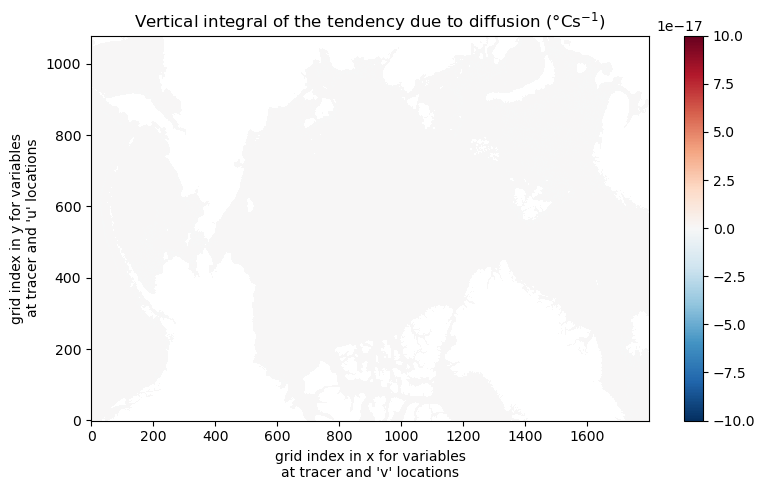

In [151]:
sassie_vert_int_diff.plot(cmap='RdBu_r',vmin=-1e-16,vmax=1e-16,figsize=[9,5]);
plt.title("Vertical integral of the tendency due to diffusion ($\degree$Cs$^{-1}$)");

#### plot vertical integral of the tendency due to advection

In [152]:
sassie_vert_int_adv = degC_vertical_int(G_advection_sassie, c_p_sassie, rhoconst_sassie, vol_sassie)

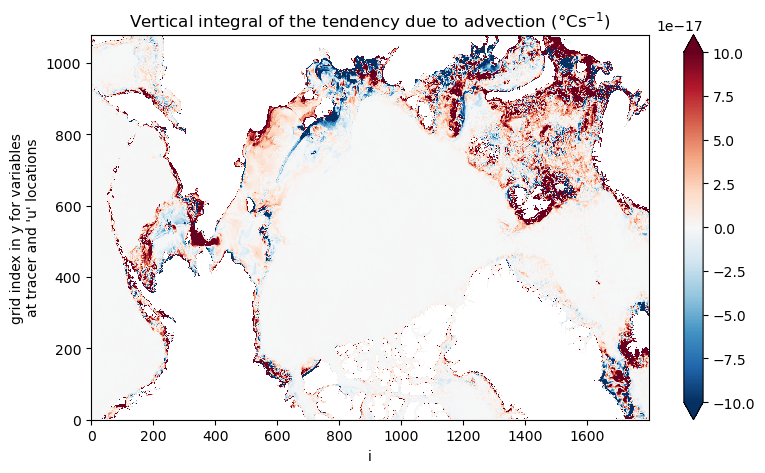

In [155]:
sassie_vert_int_adv.plot(cmap='RdBu_r',vmin=-1e-16,vmax=1e-16,figsize=[9,5]);
plt.title("Vertical integral of the tendency due to advection ($\degree$Cs$^{-1}$)");

#### plot vertically integrated residuals

In [221]:
# get vertical integral of residuals
res_sassie_integrated = degC_vertical_int(res_sassie, c_p_sassie, rhoconst_sassie, vol_sassie)

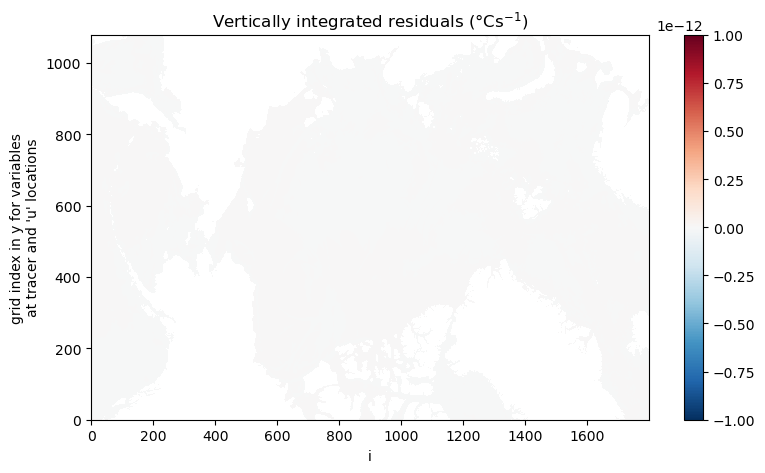

In [222]:
res_sassie_integrated.plot(cmap='RdBu_r',vmin=-1e-12,vmax=1e-12,figsize=[9,5]);
plt.title("Vertically integrated residuals ($\degree$Cs$^{-1}$)");

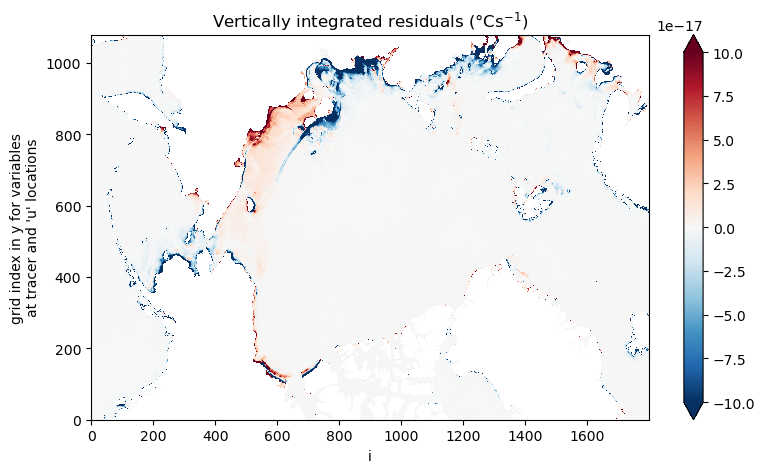

In [223]:
res_sassie_integrated.plot(cmap='RdBu_r',vmin=-1e-16,vmax=1e-16,figsize=[9,5]);
plt.title("Vertically integrated residuals ($\degree$Cs$^{-1}$)");

In [207]:
# get vertical integral of residuals
res_ecco_integrated = degC_vertical_int(res_ecco, c_p_ecco, rhoconst_ecco, vol_ecco.isel(tile=6))

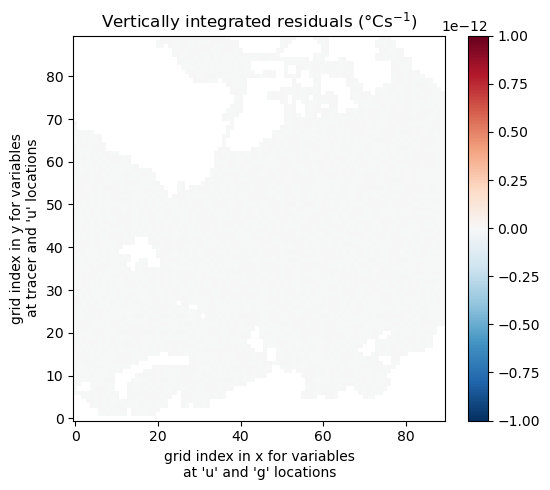

In [208]:
res_ecco_integrated.plot(cmap='RdBu_r',vmin=-1e-12,vmax=1e-12,figsize=[6,5]);
plt.title("Vertically integrated residuals ($\degree$Cs$^{-1}$)");

#### Compute cumulative sum from bottom to top

In [209]:
# Convert to J/s because we cannot sum degC/s
# [degC m3 s-1] x cp  [J kg-1 K-1] x rho [kg m-3] --> J/s
res_sassie_joules = res_sassie * c_p_sassie * rhoconst_sassie

In [210]:
# weight each grid cell by vol(k)/total vol
# volume for entire water column for each horizontal grid cell
vol_column = vol_sassie.sum('k').compute() 
# divide by total water column to get weights
vol_weights = vol_sassie / vol_column

In [211]:
# take cumulative sum from bottom to top
res_sassie_joules_cumsum = (res_sassie_joules*vol_weights).isel(k=slice(None, None, -1)).cumsum(dim='k')

# mask out land
res_sassie_joules_cumsum_wet = res_sassie_joules_cumsum.where(HH_grid.hFacC>0)

In [212]:
# convert back to degC/s

# divide by volume to get [J s-1 m-3]
tmp_cumsum = res_sassie_joules_cumsum_wet.isel(k=slice(None, None, -1)) / vol_sassie

# divide by cp and rho to convert [J s-1 m-3] to [degC/s]
res_sassie_cumsum = tmp_cumsum / c_p_sassie / rhoconst_sassie

# swap dims
res_sassie_cumsum_depth = res_sassie_cumsum.swap_dims({'k':'Z'})

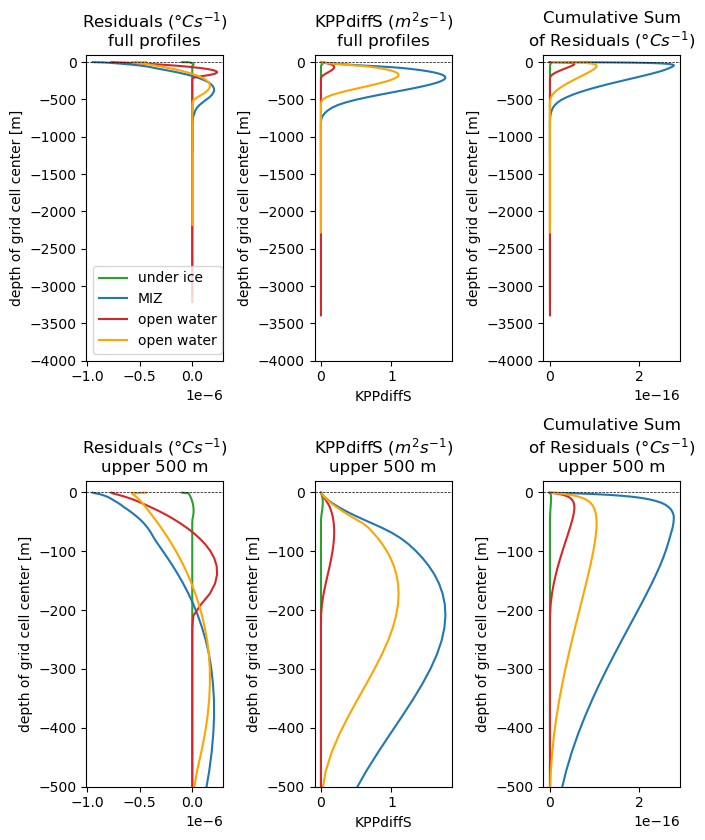

In [213]:
# plot some profiles
fig, ((ax1,ax3,ax5),(ax2,ax4,ax6)) = plt.subplots(2,3,figsize=[7,8.5])

res_sassie_depth.isel(i=900,j=600).plot(ax=ax1,y='Z',c='tab:green',label='under ice');
res_sassie_depth.isel(i=1400,j=535).plot(ax=ax1,y='Z',c='tab:blue',label='MIZ');
res_sassie_depth.isel(i=1750,j=400).plot(ax=ax1,y='Z',c='tab:red',label='open water');
res_sassie_depth.isel(i=1760,j=100).plot(ax=ax1,y='Z',c='orange',label='open water');
ax1.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax1.set_ylim(-4000,100);
ax1.set_title("Residuals ($\degree Cs^{-1}$)\nfull profiles");
ax1.legend()

res_sassie_depth.isel(i=900,j=600).plot(ax=ax2,y='Z',c='tab:green');
res_sassie_depth.isel(i=1400,j=535).plot(ax=ax2,y='Z',c='tab:blue');
res_sassie_depth.isel(i=1750,j=400).plot(ax=ax2,y='Z',c='tab:red');
res_sassie_depth.isel(i=1760,j=100).plot(ax=ax2,y='Z',c='orange');
ax2.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax2.set_ylim(-500,20);
ax2.set_title("Residuals ($\degree Cs^{-1}$)\nupper 500 m");

KPPdiffS_march.isel(i=900,j=600).plot(ax=ax3,y='Z',c='tab:green',label='under ice');
KPPdiffS_march.isel(i=1400,j=535).plot(ax=ax3,y='Z',c='tab:blue',label='MIZ');
KPPdiffS_march.isel(i=1750,j=400).plot(ax=ax3,y='Z',c='tab:red',label='open water');
KPPdiffS_march.isel(i=1760,j=100).plot(ax=ax3,y='Z',c='orange',label='open water');
ax3.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax3.set_ylim(-4000,100);
ax3.set_title("KPPdiffS ($m^2s^{-1}$)\nfull profiles");
# ax3.legend()

KPPdiffS_march.isel(i=900,j=600).plot(ax=ax4,y='Z',c='tab:green');
KPPdiffS_march.isel(i=1400,j=535).plot(ax=ax4,y='Z',c='tab:blue');
KPPdiffS_march.isel(i=1750,j=400).plot(ax=ax4,y='Z',c='tab:red');
KPPdiffS_march.isel(i=1760,j=100).plot(ax=ax4,y='Z',c='orange');
ax4.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax4.set_ylim(-500,20);
ax4.set_title("KPPdiffS ($m^2s^{-1}$)\nupper 500 m");

# cumulative sum of residuals
res_sassie_cumsum_depth.isel(i=900,j=600).plot(ax=ax5,y='Z',c='tab:green');
res_sassie_cumsum_depth.isel(i=1400,j=535).plot(ax=ax5,y='Z',c='tab:blue');
res_sassie_cumsum_depth.isel(i=1750,j=400).plot(ax=ax5,y='Z',c='tab:red');
res_sassie_cumsum_depth.isel(i=1760,j=100).plot(ax=ax5,y='Z',c='orange');
ax5.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax5.set_ylim(-4000,100);
ax5.set_title("Cumulative Sum\nof Residuals ($\degree Cs^{-1}$)");

res_sassie_cumsum_depth.isel(i=900,j=600).plot(ax=ax6,y='Z',c='tab:green');
res_sassie_cumsum_depth.isel(i=1400,j=535).plot(ax=ax6,y='Z',c='tab:blue');
res_sassie_cumsum_depth.isel(i=1750,j=400).plot(ax=ax6,y='Z',c='tab:red');
res_sassie_cumsum_depth.isel(i=1760,j=100).plot(ax=ax6,y='Z',c='orange');
ax6.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax6.set_ylim(-500,20);
ax6.set_title("Cumulative Sum\nof Residuals ($\degree Cs^{-1}$)\nupper 500 m");

plt.tight_layout()

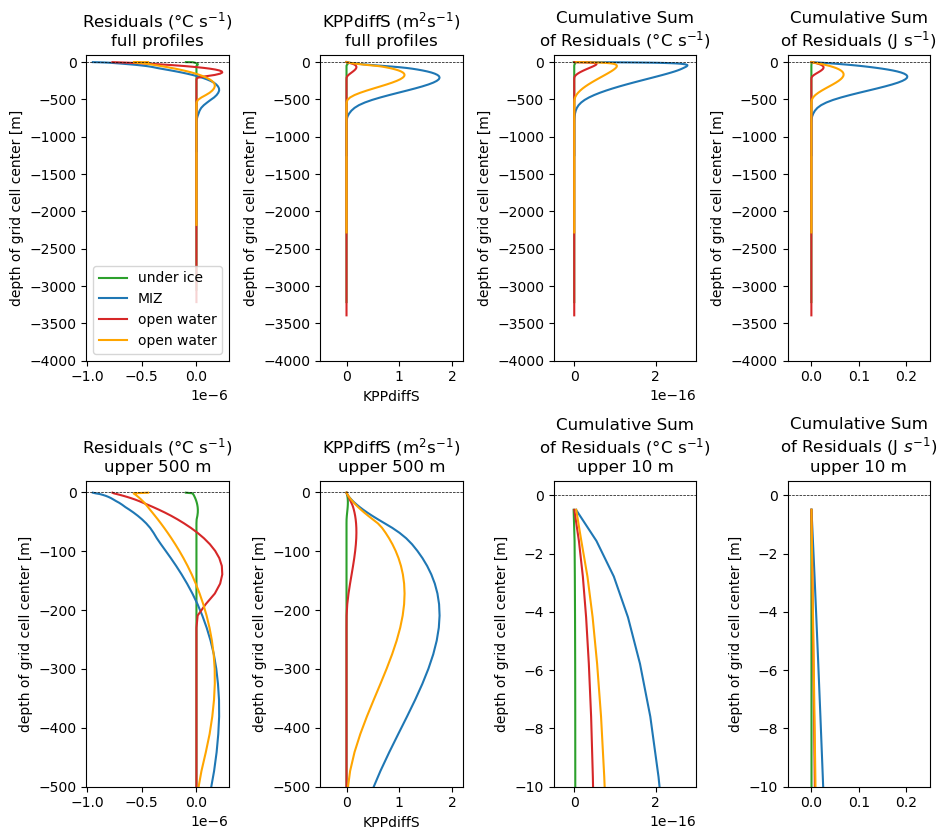

In [214]:
# plot some profiles
fig, ((ax1,ax3,ax5,ax7),(ax2,ax4,ax6,ax8)) = plt.subplots(2,4,figsize=[9.5,8.5])

res_sassie_depth.isel(i=900,j=600).plot(ax=ax1,y='Z',c='tab:green',label='under ice');
res_sassie_depth.isel(i=1400,j=535).plot(ax=ax1,y='Z',c='tab:blue',label='MIZ');
res_sassie_depth.isel(i=1750,j=400).plot(ax=ax1,y='Z',c='tab:red',label='open water');
res_sassie_depth.isel(i=1760,j=100).plot(ax=ax1,y='Z',c='orange',label='open water');
ax1.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax1.set_ylim(-4000,100);
ax1.set_title("Residuals ($\degree$C s$^{-1}$)\nfull profiles");
ax1.legend()

res_sassie_depth.isel(i=900,j=600).plot(ax=ax2,y='Z',c='tab:green');
res_sassie_depth.isel(i=1400,j=535).plot(ax=ax2,y='Z',c='tab:blue');
res_sassie_depth.isel(i=1750,j=400).plot(ax=ax2,y='Z',c='tab:red');
res_sassie_depth.isel(i=1760,j=100).plot(ax=ax2,y='Z',c='orange');
ax2.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax2.set_ylim(-500,20);
ax2.set_title("Residuals ($\degree$C s$^{-1}$)\nupper 500 m");

KPPdiffS_march.isel(i=900,j=600).plot(ax=ax3,y='Z',c='tab:green',label='under ice');
KPPdiffS_march.isel(i=1400,j=535).plot(ax=ax3,y='Z',c='tab:blue',label='MIZ');
KPPdiffS_march.isel(i=1750,j=400).plot(ax=ax3,y='Z',c='tab:red',label='open water');
KPPdiffS_march.isel(i=1760,j=100).plot(ax=ax3,y='Z',c='orange',label='open water');
ax3.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax3.set_ylim(-4000,100);
ax3.set_title("KPPdiffS (m$^2$s$^{-1}$)\nfull profiles");
# ax3.legend()

KPPdiffS_march.isel(i=900,j=600).plot(ax=ax4,y='Z',c='tab:green');
KPPdiffS_march.isel(i=1400,j=535).plot(ax=ax4,y='Z',c='tab:blue');
KPPdiffS_march.isel(i=1750,j=400).plot(ax=ax4,y='Z',c='tab:red');
KPPdiffS_march.isel(i=1760,j=100).plot(ax=ax4,y='Z',c='orange');
ax4.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax4.set_ylim(-500,20);
ax4.set_title("KPPdiffS (m$^2$s$^{-1}$)\nupper 500 m");

# cumulative sum of residuals - degC/s
res_sassie_cumsum_depth.isel(i=900,j=600).plot(ax=ax5,y='Z',c='tab:green');
res_sassie_cumsum_depth.isel(i=1400,j=535).plot(ax=ax5,y='Z',c='tab:blue');
res_sassie_cumsum_depth.isel(i=1750,j=400).plot(ax=ax5,y='Z',c='tab:red');
res_sassie_cumsum_depth.isel(i=1760,j=100).plot(ax=ax5,y='Z',c='orange');
ax5.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax5.set_ylim(-4000,100);
ax5.set_title("Cumulative Sum\nof Residuals ($\degree$C s$^{-1}$)");

res_sassie_cumsum_depth.isel(i=900,j=600).plot(ax=ax6,y='Z',c='tab:green');
res_sassie_cumsum_depth.isel(i=1400,j=535).plot(ax=ax6,y='Z',c='tab:blue');
res_sassie_cumsum_depth.isel(i=1750,j=400).plot(ax=ax6,y='Z',c='tab:red');
res_sassie_cumsum_depth.isel(i=1760,j=100).plot(ax=ax6,y='Z',c='orange');
ax6.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax6.set_ylim(-10,0.5);
ax6.set_title("Cumulative Sum\nof Residuals ($\degree$C s$^{-1}$)\nupper 10 m");

# cumulative sum of residuals - J/s
res_sassie_joules_cumsum_wet.isel(i=900,j=600).plot(ax=ax7,y='Z',c='tab:green');
res_sassie_joules_cumsum_wet.isel(i=1400,j=535).plot(ax=ax7,y='Z',c='tab:blue');
res_sassie_joules_cumsum_wet.isel(i=1750,j=400).plot(ax=ax7,y='Z',c='tab:red');
res_sassie_joules_cumsum_wet.isel(i=1760,j=100).plot(ax=ax7,y='Z',c='orange');
ax7.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax7.set_ylim(-4000,100);
ax7.set_title("Cumulative Sum\nof Residuals (J s$^{-1}$)");

res_sassie_joules_cumsum_wet.isel(i=900,j=600).plot(ax=ax8,y='Z',c='tab:green');
res_sassie_joules_cumsum_wet.isel(i=1400,j=535).plot(ax=ax8,y='Z',c='tab:blue');
res_sassie_joules_cumsum_wet.isel(i=1750,j=400).plot(ax=ax8,y='Z',c='tab:red');
res_sassie_joules_cumsum_wet.isel(i=1760,j=100).plot(ax=ax8,y='Z',c='orange');
ax8.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax8.set_ylim(-10,0.5);
ax8.set_title("Cumulative Sum\nof Residuals (J $s^{-1}$)\nupper 10 m");

# set xlim
ax3.set_xlim(-0.5,2.2)
ax4.set_xlim(-0.5,2.2)

ax5.set_xlim(-5e-17,3e-16)
ax6.set_xlim(-5e-17,3e-16)

ax7.set_xlim(-0.05,0.25)
ax8.set_xlim(-0.05,0.25)

plt.tight_layout()

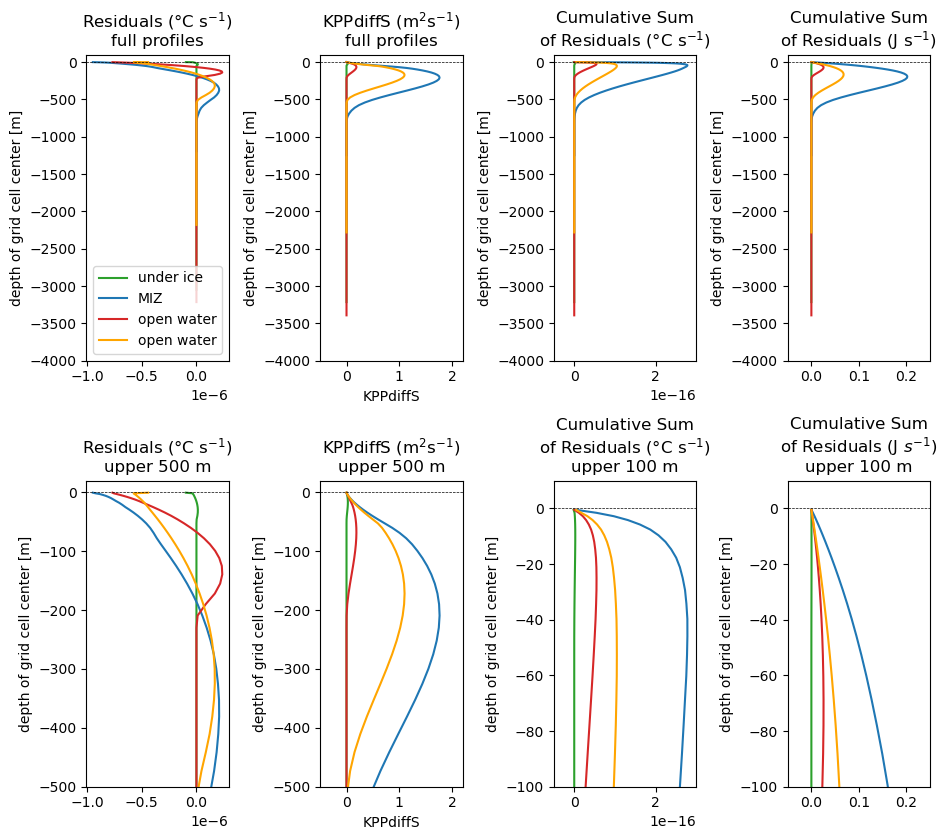

In [215]:
# plot some profiles
fig, ((ax1,ax3,ax5,ax7),(ax2,ax4,ax6,ax8)) = plt.subplots(2,4,figsize=[9.5,8.5])

res_sassie_depth.isel(i=900,j=600).plot(ax=ax1,y='Z',c='tab:green',label='under ice');
res_sassie_depth.isel(i=1400,j=535).plot(ax=ax1,y='Z',c='tab:blue',label='MIZ');
res_sassie_depth.isel(i=1750,j=400).plot(ax=ax1,y='Z',c='tab:red',label='open water');
res_sassie_depth.isel(i=1760,j=100).plot(ax=ax1,y='Z',c='orange',label='open water');
ax1.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax1.set_ylim(-4000,100);
ax1.set_title("Residuals ($\degree$C s$^{-1}$)\nfull profiles");
ax1.legend()

res_sassie_depth.isel(i=900,j=600).plot(ax=ax2,y='Z',c='tab:green');
res_sassie_depth.isel(i=1400,j=535).plot(ax=ax2,y='Z',c='tab:blue');
res_sassie_depth.isel(i=1750,j=400).plot(ax=ax2,y='Z',c='tab:red');
res_sassie_depth.isel(i=1760,j=100).plot(ax=ax2,y='Z',c='orange');
ax2.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax2.set_ylim(-500,20);
ax2.set_title("Residuals ($\degree$C s$^{-1}$)\nupper 500 m");

KPPdiffS_march.isel(i=900,j=600).plot(ax=ax3,y='Z',c='tab:green',label='under ice');
KPPdiffS_march.isel(i=1400,j=535).plot(ax=ax3,y='Z',c='tab:blue',label='MIZ');
KPPdiffS_march.isel(i=1750,j=400).plot(ax=ax3,y='Z',c='tab:red',label='open water');
KPPdiffS_march.isel(i=1760,j=100).plot(ax=ax3,y='Z',c='orange',label='open water');
ax3.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax3.set_ylim(-4000,100);
ax3.set_title("KPPdiffS (m$^2$s$^{-1}$)\nfull profiles");
# ax3.legend()

KPPdiffS_march.isel(i=900,j=600).plot(ax=ax4,y='Z',c='tab:green');
KPPdiffS_march.isel(i=1400,j=535).plot(ax=ax4,y='Z',c='tab:blue');
KPPdiffS_march.isel(i=1750,j=400).plot(ax=ax4,y='Z',c='tab:red');
KPPdiffS_march.isel(i=1760,j=100).plot(ax=ax4,y='Z',c='orange');
ax4.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax4.set_ylim(-500,20);
ax4.set_title("KPPdiffS (m$^2$s$^{-1}$)\nupper 500 m");

# cumulative sum of residuals - degC/s
res_sassie_cumsum_depth.isel(i=900,j=600).plot(ax=ax5,y='Z',c='tab:green');
res_sassie_cumsum_depth.isel(i=1400,j=535).plot(ax=ax5,y='Z',c='tab:blue');
res_sassie_cumsum_depth.isel(i=1750,j=400).plot(ax=ax5,y='Z',c='tab:red');
res_sassie_cumsum_depth.isel(i=1760,j=100).plot(ax=ax5,y='Z',c='orange');
ax5.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax5.set_ylim(-4000,100);
ax5.set_title("Cumulative Sum\nof Residuals ($\degree$C s$^{-1}$)");

res_sassie_cumsum_depth.isel(i=900,j=600).plot(ax=ax6,y='Z',c='tab:green');
res_sassie_cumsum_depth.isel(i=1400,j=535).plot(ax=ax6,y='Z',c='tab:blue');
res_sassie_cumsum_depth.isel(i=1750,j=400).plot(ax=ax6,y='Z',c='tab:red');
res_sassie_cumsum_depth.isel(i=1760,j=100).plot(ax=ax6,y='Z',c='orange');
ax6.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax6.set_ylim(-100,10);
ax6.set_title("Cumulative Sum\nof Residuals ($\degree$C s$^{-1}$)\nupper 100 m");

# cumulative sum of residuals - J/s
res_sassie_joules_cumsum_wet.isel(i=900,j=600).plot(ax=ax7,y='Z',c='tab:green');
res_sassie_joules_cumsum_wet.isel(i=1400,j=535).plot(ax=ax7,y='Z',c='tab:blue');
res_sassie_joules_cumsum_wet.isel(i=1750,j=400).plot(ax=ax7,y='Z',c='tab:red');
res_sassie_joules_cumsum_wet.isel(i=1760,j=100).plot(ax=ax7,y='Z',c='orange');
ax7.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax7.set_ylim(-4000,100);
ax7.set_title("Cumulative Sum\nof Residuals (J s$^{-1}$)");

res_sassie_joules_cumsum_wet.isel(i=900,j=600).plot(ax=ax8,y='Z',c='tab:green');
res_sassie_joules_cumsum_wet.isel(i=1400,j=535).plot(ax=ax8,y='Z',c='tab:blue');
res_sassie_joules_cumsum_wet.isel(i=1750,j=400).plot(ax=ax8,y='Z',c='tab:red');
res_sassie_joules_cumsum_wet.isel(i=1760,j=100).plot(ax=ax8,y='Z',c='orange');
ax8.axhline(y=0,c='k',linestyle='dashed',linewidth=0.5)
ax8.set_ylim(-100,10);
ax8.set_title("Cumulative Sum\nof Residuals (J $s^{-1}$)\nupper 100 m");

# set xlim
ax3.set_xlim(-0.5,2.2)
ax4.set_xlim(-0.5,2.2)

ax5.set_xlim(-5e-17,3e-16)
ax6.set_xlim(-5e-17,3e-16)

ax7.set_xlim(-0.05,0.25)
ax8.set_xlim(-0.05,0.25)

plt.tight_layout()

In [216]:
res_sassie_cumsum_depth.isel(i=900,j=600,Z=0).Z.values

array(-0.5, dtype=float32)

In [217]:
print(res_sassie_cumsum_depth.isel(i=900,j=600,Z=0).values)
print(res_sassie_cumsum_depth.isel(i=1400,j=535,Z=0).values)
print(res_sassie_cumsum_depth.isel(i=1750,j=400,Z=0).values)
print(res_sassie_cumsum_depth.isel(i=1760,j=100,Z=0).values)

-1.4944620540078137e-18
4.485864251961295e-18
2.0709908468937793e-19
4.819913326610594e-18


In [218]:
print(res_sassie_cumsum_depth.isel(i=900,j=600,Z=-1).values)
print(res_sassie_cumsum_depth.isel(i=1400,j=535,Z=-1).values)
print(res_sassie_cumsum_depth.isel(i=1750,j=400,Z=-1).values)
print(res_sassie_cumsum_depth.isel(i=1760,j=100,Z=-1).values)

nan
nan
nan
nan


In [219]:
res_sassie_joules_cumsum_wet.isel(i=900,j=600,k=-1).Z.values

array(-0.5, dtype=float32)

In [220]:
print(res_sassie_joules_cumsum_wet.isel(i=900,j=600,k=-1).values)
print(res_sassie_joules_cumsum_wet.isel(i=1400,j=535,k=-1).values)
print(res_sassie_joules_cumsum_wet.isel(i=1750,j=400,k=-1).values)
print(res_sassie_joules_cumsum_wet.isel(i=1760,j=100,k=-1).values)

-7.358115036774465e-05
0.0002366918223645851
1.4533624773842312e-05
0.00024825112747856796


In [221]:
print(res_sassie_joules_cumsum_wet.isel(i=900,j=600,k=0).values)
print(res_sassie_joules_cumsum_wet.isel(i=1400,j=535,k=0).values)
print(res_sassie_joules_cumsum_wet.isel(i=1750,j=400,k=0).values)
print(res_sassie_joules_cumsum_wet.isel(i=1760,j=100,k=0).values)

nan
nan
nan
nan
